In [1]:
import rdkit
import pandas
import numpy
import sklearn
import matplotlib
import seaborn
import xgboost
from chembl_webresource_client.new_client import new_client

print("RDKit:", rdkit.__version__)
print("Pandas:", pandas.__version__)
print("Numpy:", numpy.__version__)
print("Sklearn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", seaborn.__version__)
print("ChEMBL client: OK")

C:\Users\DELL\anaconda3\envs\tox21\lib\site-packages\chembl_webresource_client\__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


RDKit: 2025.09.5
Pandas: 2.3.3
Numpy: 1.23.5
Sklearn: 1.7.2
XGBoost: 2.1.3
Matplotlib: 3.10.8
Seaborn: 0.13.2
ChEMBL client: OK


## 1. Fetch LpxC Data from ChEMBL

In [2]:
from chembl_webresource_client.new_client import new_client

target = new_client.target
activity = new_client.activity

print("chembl client ready")

chembl client ready


## 2. Search for LpxC Target

In [4]:
# Search for LpxC target in P. aeruginosa
target_search = target.search('LpxC')

# Convert to a pandas DataFrame so we can read it easily
import pandas as pd
target_df = pd.DataFrame.from_records(target_search)

print("Columns Available: ", target_df.columns.tolist())
print("No. of Targets found: ", len(target_df))

Columns Available:  ['cross_references', 'organism', 'pref_name', 'score', 'species_group_flag', 'target_chembl_id', 'target_components', 'target_type', 'tax_id']
No. of Targets found:  6


In [5]:
target_df[['target_chembl_id', 'pref_name', 'organism', 'target_type']].head(20)

,target_chembl_id,pref_name,organism,target_type
0,CHEMBL2163170,UDP-3-O-acyl-N-acetylglucosamine deacetylase,Pseudomonas aeruginosa,SINGLE PROTEIN
1,CHEMBL2163170,UDP-3-O-acyl-N-acetylglucosamine deacetylase,Pseudomonas aeruginosa,SINGLE PROTEIN
2,CHEMBL4296297,UDP-3-O-acyl-N-acetylglucosamine deacetylase,Rhizobium leguminosarum bv. trifolii (strain W...,SINGLE PROTEIN
3,CHEMBL3855,UDP-3-O-acyl-N-acetylglucosamine deacetylase,Pseudomonas aeruginosa (strain ATCC 15692 / PA...,SINGLE PROTEIN
4,CHEMBL1075040,UDP-3-O-acyl-N-acetylglucosamine deacetylase,Aquifex aeolicus (strain VF5),SINGLE PROTEIN
5,CHEMBL5244,UDP-3-O-acyl-N-acetylglucosamine deacetylase,Escherichia coli K-12,SINGLE PROTEIN


## 3. Store the Target ID

In [6]:
lpxc_target_id = 'CHEMBL3855'

print("Target ID confirmed:", lpxc_target_id)
print("Organism: Pseudomonas aeruginosa")
print("Target: LpxC (UDP-3-O-acyl-N-acetylglucosamine deacetylase)")

Target ID confirmed: CHEMBL3855
Organism: Pseudomonas aeruginosa
Target: LpxC (UDP-3-O-acyl-N-acetylglucosamine deacetylase)


## 4. Fetch Activity Data

In [7]:
activities = activity.filter(
    target_chembl_id = lpxc_target_id,
    standard_type='IC50'
)


In [8]:
df = pd.DataFrame.from_records(activities)

print("Total records fetched:", len(df))
print("Columns available:", df.columns.tolist())

Total records fetched: 588
Columns available: ['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value']


## 5. Keep only what we need 

In [9]:

df_clean = df[[
    'molecule_chembl_id',
    'canonical_smiles',
    'standard_value',
    'standard_units',
    'standard_relation'
]].copy()

print("Shape:", df_clean.shape)
print("\nFirst 5 rows:")
df_clean.head()

Shape: (588, 5)

First 5 rows:


,molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_relation
0,CHEMBL107174,Cc1c(C2=NC(C(=O)NO)CS2)cnn1-c1ccccc1,60000.0,nM,>
1,CHEMBL107174,Cc1c(C2=NC(C(=O)NO)CS2)cnn1-c1ccccc1,60000.0,nM,>
2,CHEMBL106879,O=C(NO)C1COC(c2ccc([N+](=O)[O-])cc2)=N1,5400.0,nM,=
3,CHEMBL106826,CCCCn1nc(C2=NC(C(=O)NO)CO2)c2ccccc21,10000.0,nM,=
4,CHEMBL105262,COc1c(F)cc(C2=NC(C(=O)NO)CO2)cc1Br,9000.0,nM,=


## 6. Data Cleaning 

In [10]:
# keep only nM Units
df_clean = df_clean[df_clean['standard_units'] == 'nM']

#keep only exact measurements (relation = )
df_clean = df_clean[df_clean['standard_relation'] == '=']

# drop missing values
df_clean = df_clean.dropna(subset=['canonical_smiles', 'standard_value'])

#remove duplicates
df_clean = df_clean.drop_duplicates(subset=['molecule_chembl_id'])

#reset index
df_clean = df_clean.reset_index(drop=True)

print("Records after cleaning:", len(df_clean))
df_clean.head()

Records after cleaning: 492


,molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_relation
0,CHEMBL106879,O=C(NO)C1COC(c2ccc([N+](=O)[O-])cc2)=N1,5400.0,nM,=
1,CHEMBL106826,CCCCn1nc(C2=NC(C(=O)NO)CO2)c2ccccc21,10000.0,nM,=
2,CHEMBL105262,COc1c(F)cc(C2=NC(C(=O)NO)CO2)cc1Br,9000.0,nM,=
3,CHEMBL324440,O=C(NO)C1COC(c2cc3cc(F)ccc3[nH]2)=N1,1600.0,nM,=
4,CHEMBL319430,O=C(NO)C1CCOC(c2ccc(F)c(C(F)(F)F)c2)=N1,21200.0,nM,=


## 7. Convert IC50 to pIC50

In [12]:
import numpy as np

# Convert standard_value to numeric first (fix the string issue)
df_clean['standard_value'] = pd.to_numeric(df_clean['standard_value'], errors='coerce')

# Drop any rows that couldn't be converted
df_clean = df_clean.dropna(subset=['standard_value'])

# Now convert IC50 from nM to Molar, then calculate pIC50
df_clean['pIC50'] = -np.log10(df_clean['standard_value'] * 1e-9)

print("pIC50 column added ")
print("\nSample values:")
print(df_clean[['molecule_chembl_id', 'standard_value', 'pIC50']].head(10))
print("\npIC50 stats:")
print(df_clean['pIC50'].describe())

pIC50 column added 

Sample values:
  molecule_chembl_id  standard_value     pIC50
0       CHEMBL106879          5400.0  5.267606
1       CHEMBL106826         10000.0  5.000000
2       CHEMBL105262          9000.0  5.045757
3       CHEMBL324440          1600.0  5.795880
4       CHEMBL319430         21200.0  4.673664
5       CHEMBL104671         30000.0  4.522879
6       CHEMBL320155         12000.0  4.920819
7       CHEMBL242031         13000.0  4.886057
8       CHEMBL106989          5600.0  5.251812
9       CHEMBL107004          5500.0  5.259637

pIC50 stats:
count    492.000000
mean       7.710774
std        1.616521
min        2.555955
25%        6.856081
50%        8.199627
75%        8.866461
max       10.698970
Name: pIC50, dtype: float64


## 8. Add Activity Labels

In [13]:
# Label compounds as Active (1) or Inactive (0)
df_clean['activity'] = df_clean['pIC50'].apply(
    lambda x: 1 if x >= 6 else 0
)

# Check the balance
active = df_clean['activity'].sum()
inactive = len(df_clean) - active

print("Active compounds:", active)
print("Inactive compounds:", inactive)
print("Total:", len(df_clean))
print("\nClass balance:")
print(df_clean['activity'].value_counts())

Active compounds: 398
Inactive compounds: 94
Total: 492

Class balance:
activity
1    398
0     94
Name: count, dtype: int64


## 9. Save work as csv

In [14]:
# Save cleaned dataset
df_clean.to_csv('lpxc_cleaned.csv', index=False)

print("Dataset saved as lpxc_cleaned.csv ✅")
print("Shape:", df_clean.shape)
print("Columns:", df_clean.columns.tolist())

Dataset saved as lpxc_cleaned.csv ✅
Shape: (492, 7)
Columns: ['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units', 'standard_relation', 'pIC50', 'activity']


## 10. Calculate RDKit Descriptors

In [15]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
import numpy as np

# Get the full list of available descriptors
descriptor_names = [d[0] for d in Descriptors.descList]

print("Total descriptors available:", len(descriptor_names))
print("\nFirst 10 descriptor names:")
print(descriptor_names[:10])

Total descriptors available: 217

First 10 descriptor names:
['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons']


In [16]:
# Set up the descriptor calculator with all 217 descriptors
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

# Empty list to store results
descriptor_list = []
valid_indices = []

# Loop through every SMILES in our dataset
for i, smiles in enumerate(df_clean['canonical_smiles']):
    
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    # Check if molecule is valid
    if mol is not None:
        # Calculate all 217 descriptors
        descriptors = calculator.CalcDescriptors(mol)
        descriptor_list.append(descriptors)
        valid_indices.append(i)
    else:
        print(f"Invalid SMILES at index {i} — skipped")

# Convert to DataFrame
descriptor_df = pd.DataFrame(descriptor_list, columns=descriptor_names)

print("Descriptors calculated ✅")
print("Shape:", descriptor_df.shape)
print("\nFirst 5 rows, first 5 columns:")
descriptor_df.iloc[:5, :5]

Descriptors calculated ✅
Shape: (492, 217)

First 5 rows, first 5 columns:


,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed
0,11.096870,11.096870,0.026502,-0.805378,0.453572
1,11.427289,11.427289,0.109002,-0.736524,0.646647
2,13.701755,13.701755,0.006950,-0.843576,0.644457
3,13.080719,13.080719,0.060965,-0.774863,0.556780
4,13.194410,13.194410,0.037349,-4.850005,0.497786


## 11. — Combine Everything into One Final Dataset

In [17]:
# Get the matching rows from df_clean (only valid molecules)
df_valid = df_clean.iloc[valid_indices].reset_index(drop=True)

# Combine descriptors with our labels
final_df = pd.concat([
    df_valid[['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'pIC50', 'activity']],
    descriptor_df
], axis=1)

print("Final dataset shape:", final_df.shape)
print("\nColumns overview:")
print("ID + SMILES + IC50 + pIC50 + activity = 5 columns")
print("Descriptors = 217 columns")
print("Total =", final_df.shape[1], "columns")
print("\nActivity distribution:")
print(final_df['activity'].value_counts())

Final dataset shape: (492, 222)

Columns overview:
ID + SMILES + IC50 + pIC50 + activity = 5 columns
Descriptors = 217 columns
Total = 222 columns

Activity distribution:
activity
1    398
0     94
Name: count, dtype: int64


In [18]:
# Save the complete ML-ready dataset
final_df.to_csv('lpxc_final_dataset.csv', index=False)

print("Final dataset saved as lpxc_final_dataset.csv ✅")

Final dataset saved as lpxc_final_dataset.csv ✅


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Plotting libraries ready ✅")

Plotting libraries ready ✅


## 12. pIC50 Distribution plot

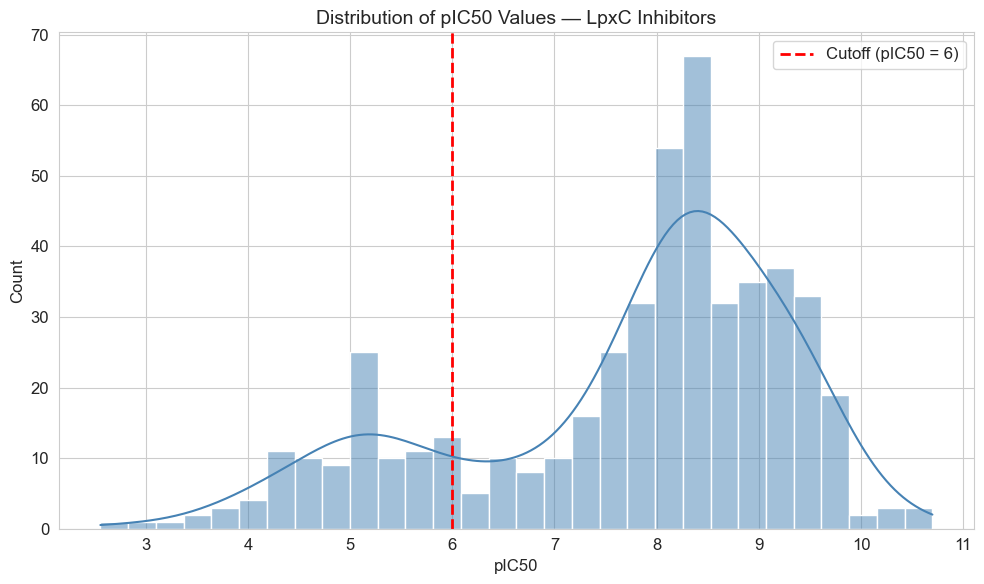

Plot saved ✅


In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=final_df,
    x='pIC50',
    bins=30,
    kde=True,
    color='steelblue'
)

# Add vertical line at cutoff
plt.axvline(x=6, color='red', linestyle='--', linewidth=2, label='Cutoff (pIC50 = 6)')

plt.title('Distribution of pIC50 Values — LpxC Inhibitors', fontsize=14)
plt.xlabel('pIC50')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('pic50_distribution.png', dpi=150)
plt.show()

print("Plot saved ✅")

## Active vs Inactive Count Plot

C:\Users\DELL\AppData\Local\Temp\ipykernel_22996\921010972.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


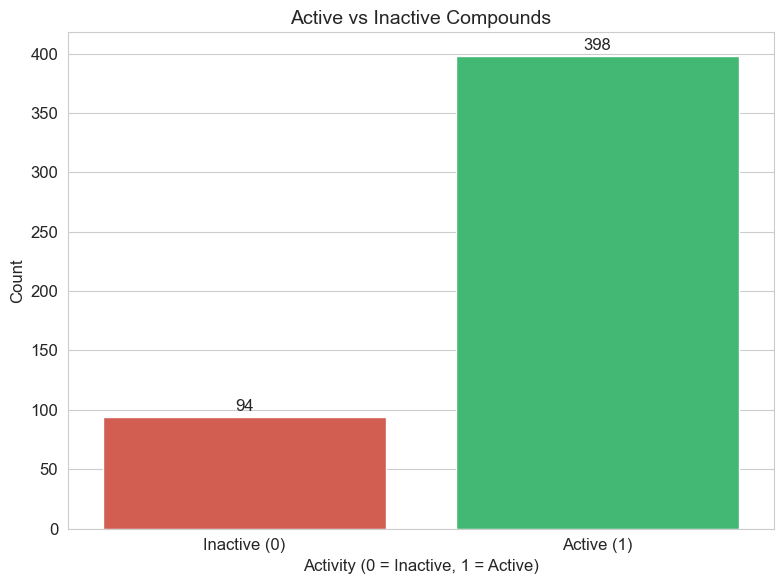

In [21]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=final_df,
    x='activity',
    palette=['#e74c3c', '#2ecc71']
)

plt.title('Active vs Inactive Compounds', fontsize=14)
plt.xlabel('Activity (0 = Inactive, 1 = Active)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Inactive (0)', 'Active (1)'])

# Add count labels on bars
for i, count in enumerate([94, 398]):
    plt.text(i, count + 5, str(count), ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()

## Compare Key Descriptors: Active vs Inactive

C:\Users\DELL\AppData\Local\Temp\ipykernel_22996\2311132079.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_22996\2311132079.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_22996\2311132079.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\DELL\AppData\Local\Temp\ipykernel_22996\2311132079.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

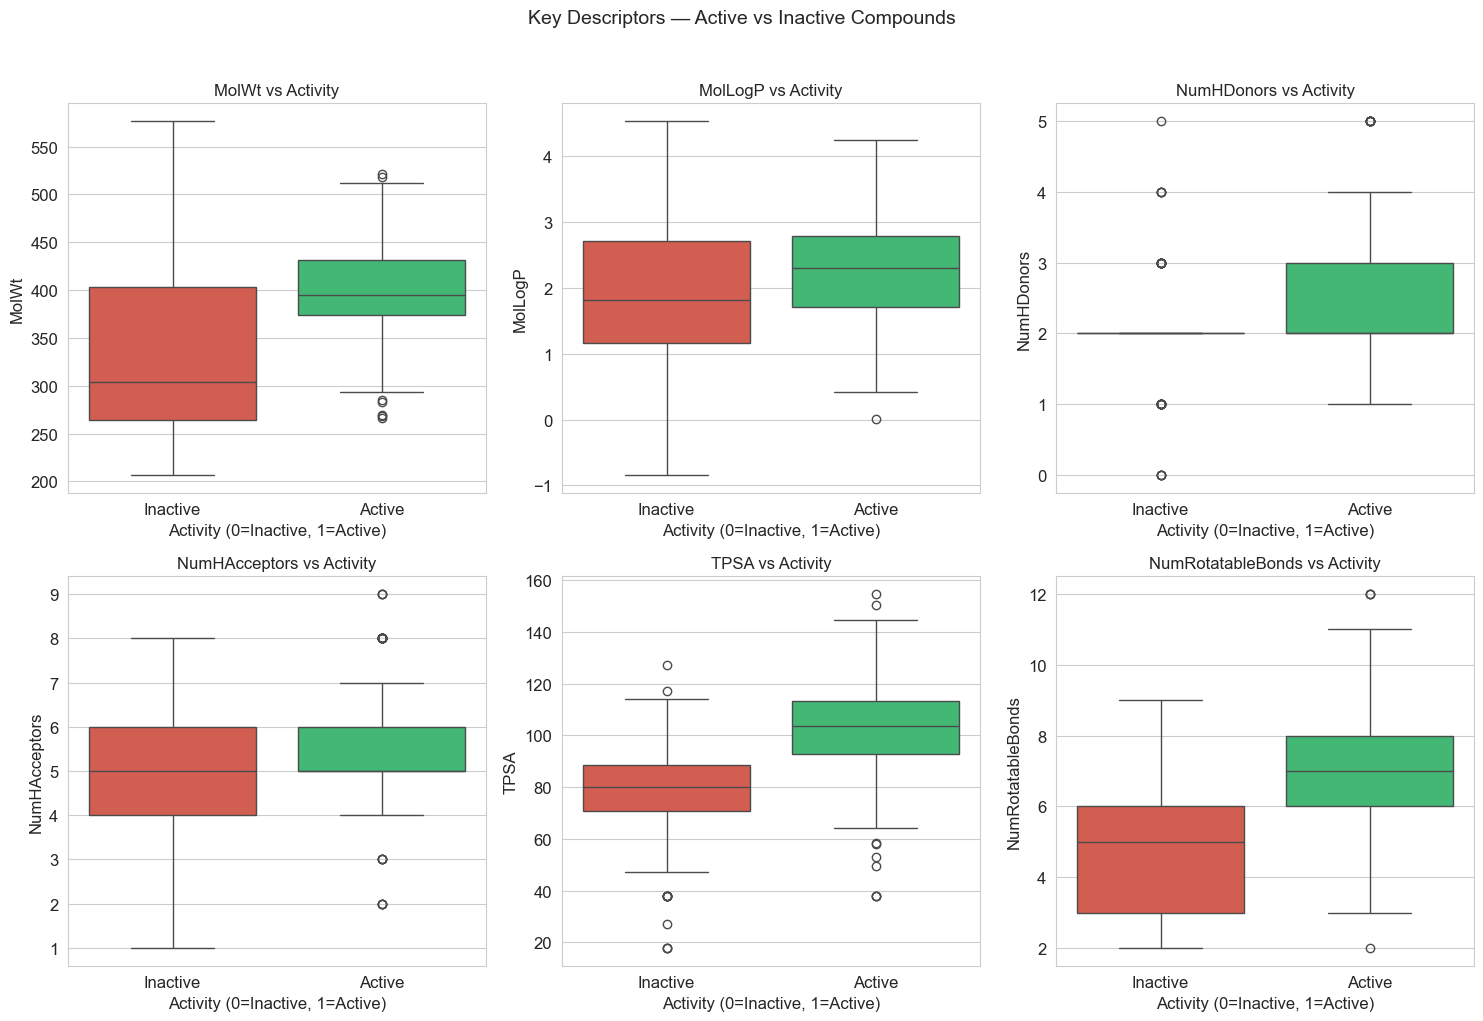

In [22]:
# Pick 6 important physicochemical descriptors to visualize
key_descriptors = ['MolWt', 'MolLogP', 'NumHDonors', 
                   'NumHAcceptors', 'TPSA', 'NumRotatableBonds']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, desc in enumerate(key_descriptors):
    sns.boxplot(
        data=final_df,
        x='activity',
        y=desc,
        palette=['#e74c3c', '#2ecc71'],
        ax=axes[i]
    )
    axes[i].set_title(f'{desc} vs Activity', fontsize=12)
    axes[i].set_xlabel('Activity (0=Inactive, 1=Active)')
    axes[i].set_ylabel(desc)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Inactive', 'Active'])

plt.suptitle('Key Descriptors — Active vs Inactive Compounds', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('descriptor_comparison.png', dpi=150)
plt.show()

## Correlation Heatmap

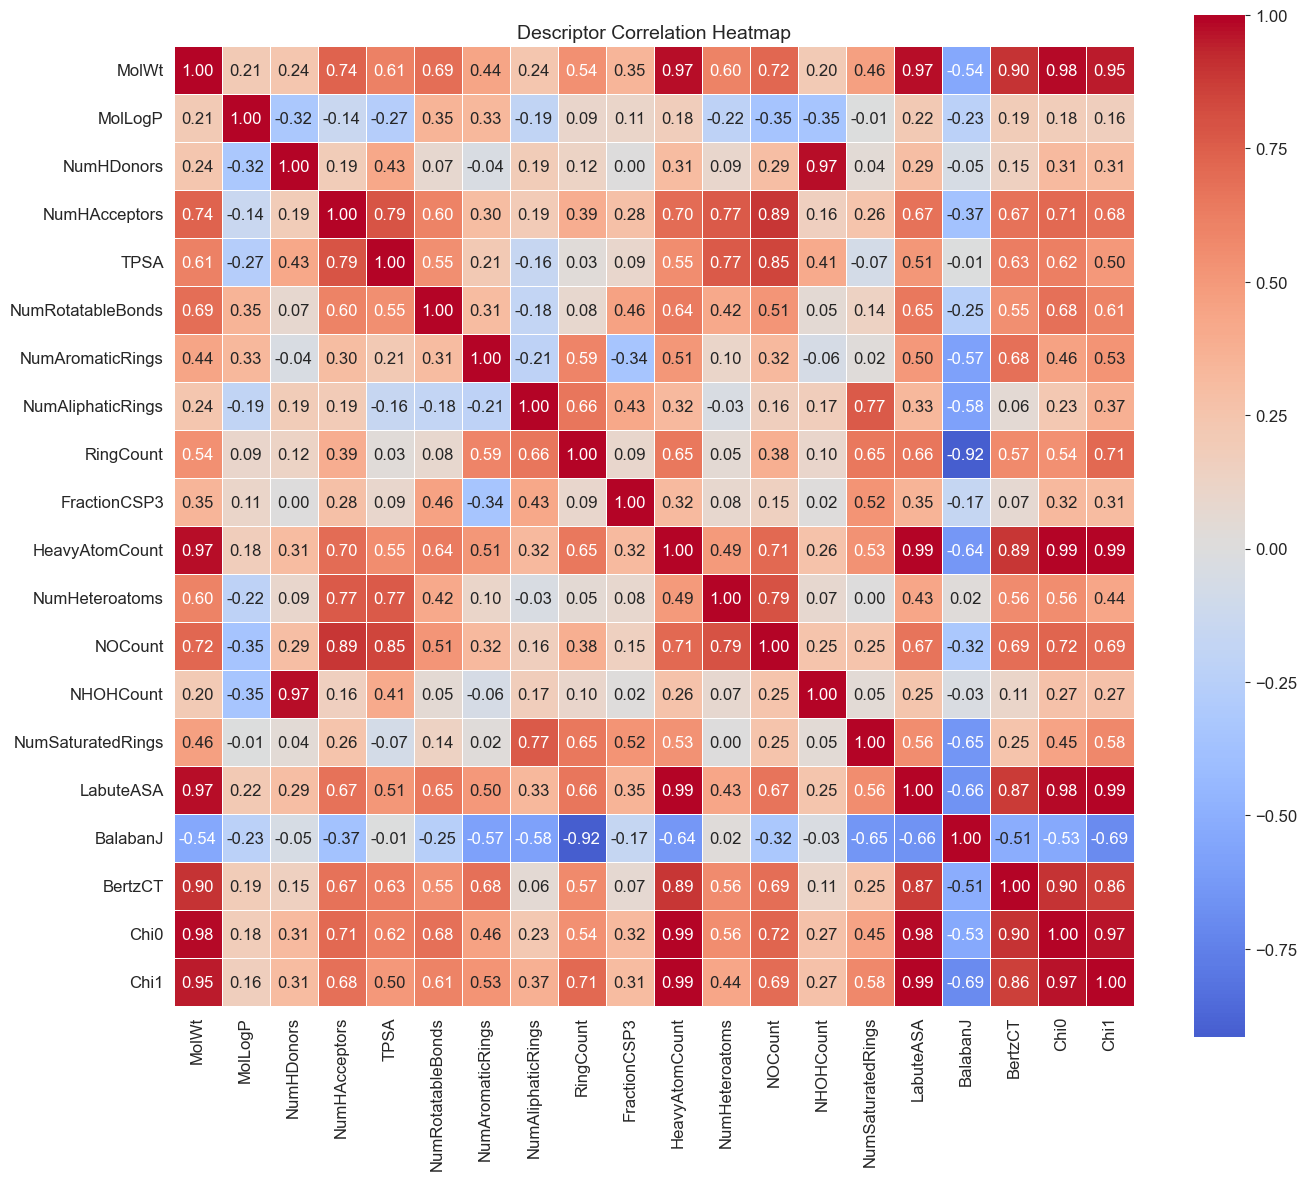

In [23]:
# Calculate correlation matrix for all 217 descriptors
descriptor_cols = descriptor_names
corr_matrix = final_df[descriptor_cols].corr().abs()

# Plot heatmap of top 20 descriptors only (full 217 would be unreadable)
top_descriptors = ['MolWt', 'MolLogP', 'NumHDonors', 'NumHAcceptors',
                   'TPSA', 'NumRotatableBonds', 'NumAromaticRings',
                   'NumAliphaticRings', 'RingCount', 'FractionCSP3',
                   'HeavyAtomCount', 'NumHeteroatoms', 'NOCount',
                   'NHOHCount', 'NumSaturatedRings', 'LabuteASA',
                   'BalabanJ', 'BertzCT', 'Chi0', 'Chi1']

plt.figure(figsize=(14, 12))
sns.heatmap(
    final_df[top_descriptors].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)

plt.title('Descriptor Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## remove Highly Correlated descriptors

In [25]:
# Calculate full correlation matrix for all 217 descriptors
corr_matrix = final_df[descriptor_names].corr().abs()

# Select upper triangle of correlation matrix
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find descriptors with correlation > 0.95
to_drop = [col for col in upper_triangle.columns 
           if any(upper_triangle[col] > 0.95)]

print("Descriptors to drop (corr > 0.95):", len(to_drop))
print("\nRemaining descriptors:", len(descriptor_names) - len(to_drop))
print("\nExample dropped descriptors:", to_drop[:10])

Descriptors to drop (corr > 0.95): 38

Remaining descriptors: 179

Example dropped descriptors: ['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MinAbsPartialCharge', 'FpDensityMorgan2', 'FpDensityMorgan3', 'Chi0', 'Chi0n', 'Chi0v']


## Apply the Filter

In [26]:
# Keep only non-correlated descriptors
clean_descriptors = [d for d in descriptor_names if d not in to_drop]

# Create clean feature matrix
X = final_df[clean_descriptors].copy()
y = final_df['activity'].copy()

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Feature matrix shape: (492, 179)
Target variable shape: (492,)

Class distribution:
activity
1    398
0     94
Name: count, dtype: int64


## Handle Missing Values in Descriptors

In [27]:
# Check for missing values
missing = X.isnull().sum()
missing_cols = missing[missing > 0]

print("Descriptors with missing values:", len(missing_cols))
print("\nMissing value details:")
print(missing_cols)

# Fill missing values with column median
X = X.fillna(X.median())

print("\nAfter filling — missing values remaining:", X.isnull().sum().sum())

Descriptors with missing values: 0

Missing value details:
Series([], dtype: int64)

After filling — missing values remaining: 0


## Train/Test split

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())

Training set: (393, 179)
Test set: (99, 179)

Training class distribution:
activity
1    318
0     75
Name: count, dtype: int64

Test class distribution:
activity
1    80
0    19
Name: count, dtype: int64


## Train  RandomForest

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest trained ✅")
print("Number of trees:", rf_model.n_estimators)
print("Number of features used:", rf_model.n_features_in_)

Random Forest trained ✅
Number of trees: 100
Number of features used: 179


##  Evaluate Random Forest

In [30]:
from sklearn.metrics import (classification_report, 
                              confusion_matrix, 
                              roc_auc_score,
                              accuracy_score)

# Make predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("=" * 40)
print("RANDOM FOREST RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Inactive', 'Active']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

RANDOM FOREST RESULTS
Accuracy:  0.9697
ROC-AUC:   0.9806

Classification Report:
              precision    recall  f1-score   support

    Inactive       1.00      0.84      0.91        19
      Active       0.96      1.00      0.98        80

    accuracy                           0.97        99
   macro avg       0.98      0.92      0.95        99
weighted avg       0.97      0.97      0.97        99


Confusion Matrix:
[[16  3]
 [ 0 80]]


## Train XGBoost

In [31]:
from xgboost import XGBClassifier

# Calculate scale for imbalanced classes
scale = len(y_train[y_train==0]) / len(y_train[y_train==1])

# Initialize XGBoost
xgb_model = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost trained ✅")
print("Scale pos weight used:", round(scale, 3))

XGBoost trained ✅
Scale pos weight used: 0.236


##  Evaluate XGBoost

In [33]:
# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=" * 40)
print("XGBOOST RESULTS")
print("=" * 40)
print(f"Accuracy:  {accuracy_xgb:.4f}")
print(f"ROC-AUC:   {roc_auc_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Inactive', 'Active']))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBOOST RESULTS
Accuracy:  0.9293
ROC-AUC:   0.9842

Classification Report:
              precision    recall  f1-score   support

    Inactive       0.77      0.89      0.83        19
      Active       0.97      0.94      0.96        80

    accuracy                           0.93        99
   macro avg       0.87      0.92      0.89        99
weighted avg       0.94      0.93      0.93        99


Confusion Matrix:
[[17  2]
 [ 5 75]]


# ROC Curve Comparison

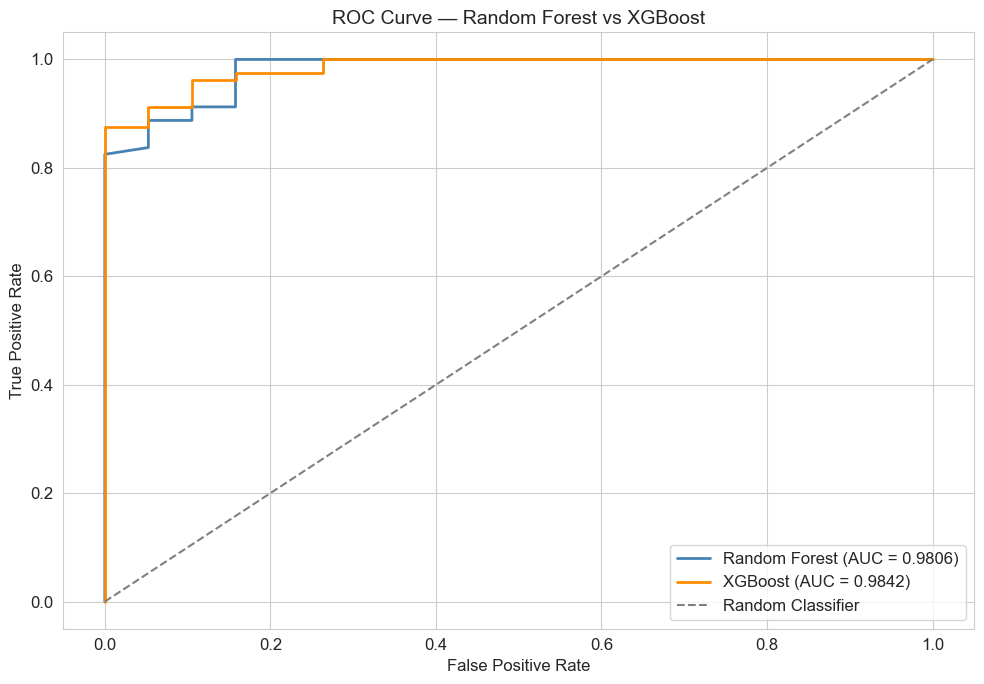

In [34]:
from sklearn.metrics import roc_curve

# Get ROC curve data for both models
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(10, 7))

# Plot Random Forest ROC
plt.plot(fpr_rf, tpr_rf, 
         color='steelblue', 
         linewidth=2,
         label=f'Random Forest (AUC = {roc_auc:.4f})')

# Plot XGBoost ROC
plt.plot(fpr_xgb, tpr_xgb,
         color='darkorange',
         linewidth=2,
         label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')

# Plot random classifier line
plt.plot([0, 1], [0, 1], 
         color='gray', 
         linestyle='--', 
         label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest vs XGBoost', fontsize=14)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150)
plt.show()

## Random Forest Feature Importance

C:\Users\DELL\AppData\Local\Temp\ipykernel_22996\1673872863.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


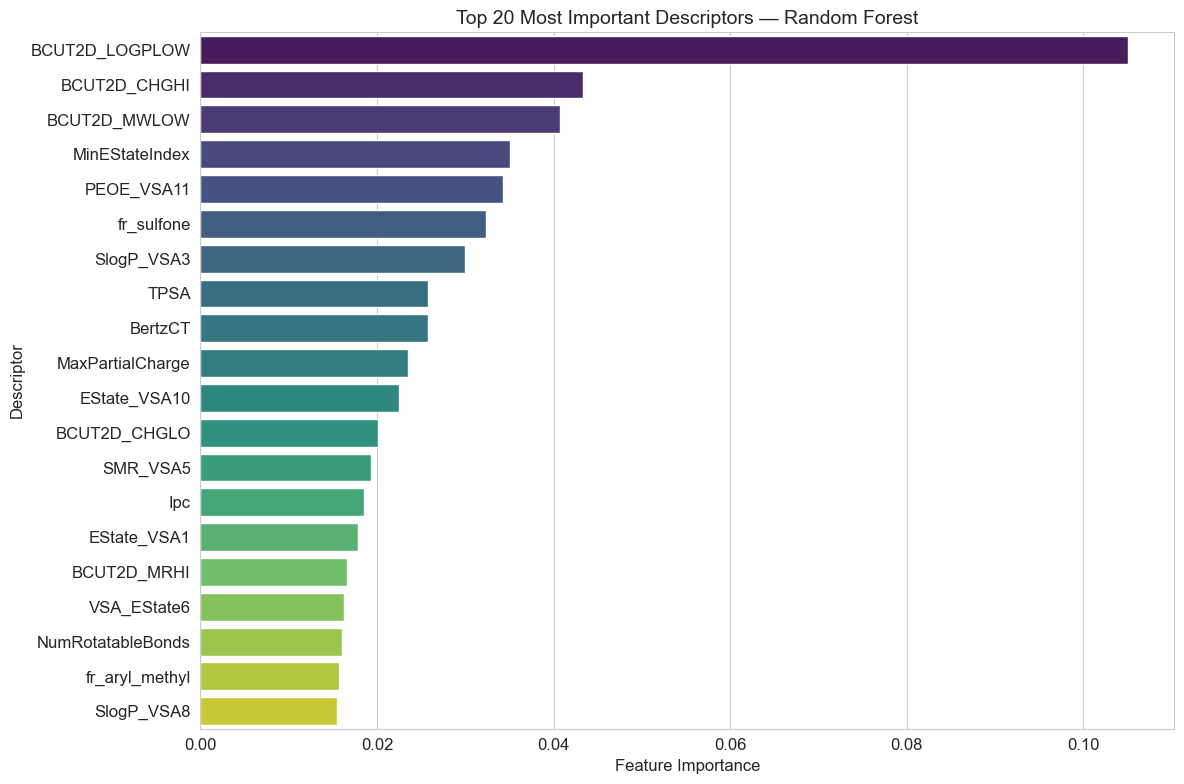

Top 10 descriptors:
      descriptor  importance
  BCUT2D_LOGPLOW    0.105035
    BCUT2D_CHGHI    0.043361
    BCUT2D_MWLOW    0.040732
  MinEStateIndex    0.035067
      PEOE_VSA11    0.034228
      fr_sulfone    0.032333
      SlogP_VSA3    0.029954
            TPSA    0.025754
         BertzCT    0.025724
MaxPartialCharge    0.023555


In [35]:
# Get feature importances from Random Forest
rf_importance = pd.DataFrame({
    'descriptor': clean_descriptors,
    'importance': rf_model.feature_importances_
})

# Sort by importance
rf_importance = rf_importance.sort_values('importance', ascending=False)

# Plot top 20
plt.figure(figsize=(12, 8))
sns.barplot(
    data=rf_importance.head(20),
    x='importance',
    y='descriptor',
    palette='viridis'
)

plt.title('Top 20 Most Important Descriptors — Random Forest', fontsize=14)
plt.xlabel('Feature Importance')
plt.ylabel('Descriptor')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150)
plt.show()

print("Top 10 descriptors:")
print(rf_importance.head(10).to_string(index=False))

##  XGBoost Feature Importance

C:\Users\DELL\AppData\Local\Temp\ipykernel_22996\1973723745.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


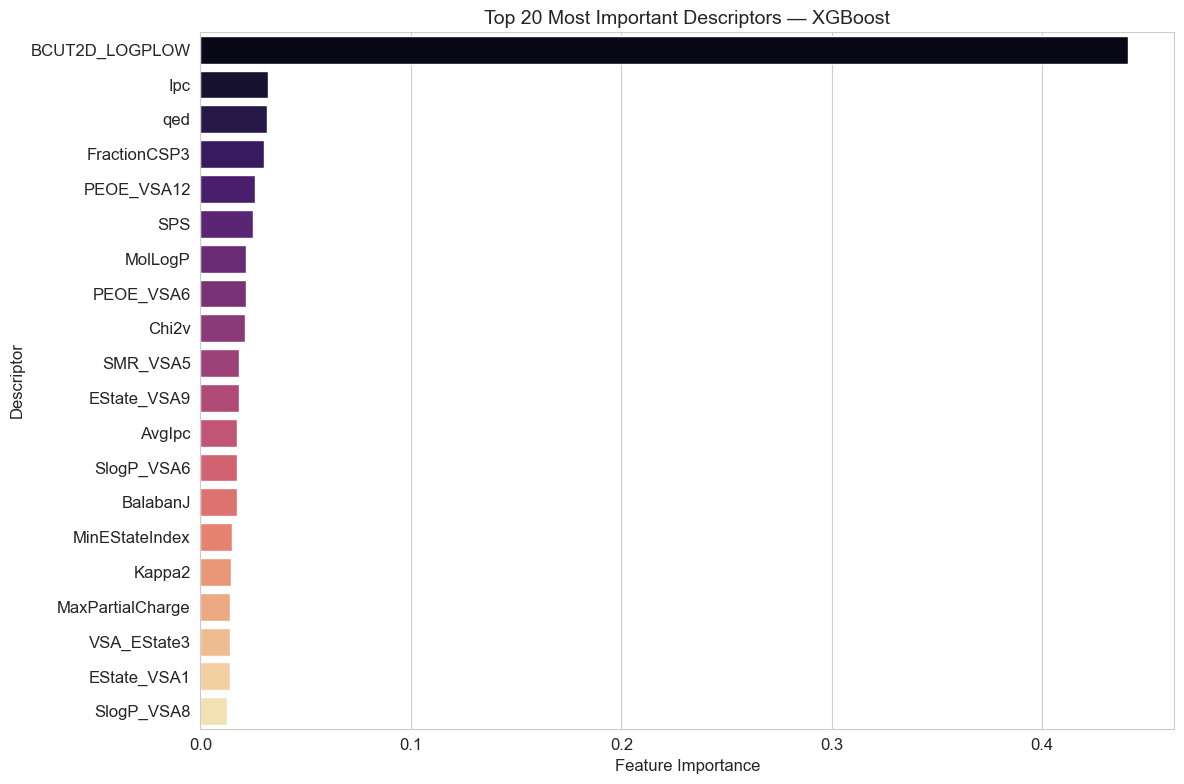

Top 10 descriptors:
    descriptor  importance
BCUT2D_LOGPLOW    0.440628
           Ipc    0.031865
           qed    0.031612
  FractionCSP3    0.030353
    PEOE_VSA12    0.026119
           SPS    0.024790
       MolLogP    0.021643
     PEOE_VSA6    0.021438
         Chi2v    0.021139
      SMR_VSA5    0.018274


In [37]:
# Get feature importances from XGBoost
xgb_importance = pd.DataFrame({
    'descriptor': clean_descriptors,
    'importance': xgb_model.feature_importances_
})

# Sort by importance
xgb_importance = xgb_importance.sort_values('importance', ascending=False)

# Plot top 20
plt.figure(figsize=(12, 8))
sns.barplot(
    data=xgb_importance.head(20),
    x='importance',
    y='descriptor',
    palette='magma'
)

plt.title('Top 20 Most Important Descriptors — XGBoost', fontsize=14)
plt.xlabel('Feature Importance')
plt.ylabel('Descriptor')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=150)
plt.show()

print("Top 10 descriptors:")
print(xgb_importance.head(10).to_string(index=False))

## Compare Both Models — Shared Top Descriptors

In [39]:
# Reset index properly for both importance dataframes
rf_importance = rf_importance.reset_index(drop=True)
xgb_importance = xgb_importance.reset_index(drop=True)

# Find shared top 20 descriptors
rf_top20 = set(rf_importance.head(20)['descriptor'])
xgb_top20 = set(xgb_importance.head(20)['descriptor'])
common = rf_top20.intersection(xgb_top20)

print(f"Shared top descriptors: {len(common)}")
print("\nDescriptors both models agree on:")
print(f"{'Descriptor':30s} {'RF Rank':>10} {'XGB Rank':>10} {'RF Importance':>15} {'XGB Importance':>15}")
print("-" * 80)

for d in sorted(common):
    rf_rank = rf_importance[rf_importance['descriptor']==d].index[0] + 1
    xgb_rank = xgb_importance[xgb_importance['descriptor']==d].index[0] + 1
    rf_imp = rf_importance[rf_importance['descriptor']==d]['importance'].values[0]
    xgb_imp = xgb_importance[xgb_importance['descriptor']==d]['importance'].values[0]
    print(f"{d:30s} {rf_rank:>10} {xgb_rank:>10} {rf_imp:>15.4f} {xgb_imp:>15.4f}")

Shared top descriptors: 7

Descriptors both models agree on:
Descriptor                        RF Rank   XGB Rank   RF Importance  XGB Importance
--------------------------------------------------------------------------------
BCUT2D_LOGPLOW                          1          1          0.1050          0.4406
EState_VSA1                            15         19          0.0179          0.0141
Ipc                                    14          2          0.0185          0.0319
MaxPartialCharge                       10         17          0.0236          0.0142
MinEStateIndex                          4         15          0.0351          0.0152
SMR_VSA5                               13         10          0.0194          0.0183
SlogP_VSA8                             20         20          0.0154          0.0127


# save Final Summary

In [40]:
# Save consensus descriptors
consensus_df = pd.DataFrame({
    'descriptor': list(common),
    'rf_rank': [rf_importance[rf_importance['descriptor']==d].index[0]+1 
                for d in common],
    'xgb_rank': [xgb_importance[xgb_importance['descriptor']==d].index[0]+1 
                 for d in common],
    'rf_importance': [rf_importance[rf_importance['descriptor']==d]['importance'].values[0] 
                      for d in common],
    'xgb_importance': [xgb_importance[xgb_importance['descriptor']==d]['importance'].values[0] 
                       for d in common]
})

consensus_df = consensus_df.sort_values('rf_rank')
consensus_df.to_csv('consensus_descriptors.csv', index=False)

print("Consensus descriptors saved ✅")
print("\nFinal model performance summary:")
print(f"Random Forest  → Accuracy: 96.97%  ROC-AUC: 0.9806")
print(f"XGBoost        → Accuracy: 92.93%  ROC-AUC: 0.9842")
print(f"\nConsensus descriptors identified: {len(common)}")
print(f"Most important descriptor: BCUT2D_LOGPLOW (both models agree)")

Consensus descriptors saved ✅

Final model performance summary:
Random Forest  → Accuracy: 96.97%  ROC-AUC: 0.9806
XGBoost        → Accuracy: 92.93%  ROC-AUC: 0.9842

Consensus descriptors identified: 7
Most important descriptor: BCUT2D_LOGPLOW (both models agree)


## Generate Morgan Fingerprints

In [41]:
from rdkit.Chem import AllChem
import numpy as np

# Empty list to store fingerprints
fingerprint_list = []

# Loop through valid SMILES
for smiles in final_df['canonical_smiles']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        # Generate Morgan Fingerprint
        # radius=2 → looks 2 bonds away from each atom
        # nBits=2048 → 2048 bit vector
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, 
            radius=2, 
            nBits=2048
        )
        fingerprint_list.append(list(fp))

# Convert to DataFrame
fp_df = pd.DataFrame(
    fingerprint_list,
    columns=[f'Morgan_{i}' for i in range(2048)]
)

print("Morgan fingerprints generated ✅")
print("Shape:", fp_df.shape)
print("\nSample — first 10 bits of first compound:")
print(fp_df.iloc[0, :10].tolist())

[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerator
[15:33:58] DEPRECATION WARNING: please use MorganGenerat

Morgan fingerprints generated ✅
Shape: (492, 2048)

Sample — first 10 bits of first compound:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


## Combine Descriptors + Fingerprints

In [43]:
# Reset indices to ensure proper alignment
descriptor_matrix = final_df[clean_descriptors].reset_index(drop=True)
fp_matrix = fp_df.reset_index(drop=True)

# Combine descriptors and fingerprints
X_combined = pd.concat([descriptor_matrix, fp_matrix], axis=1)

# Target variable stays the same
y = final_df['activity'].reset_index(drop=True)

print("Combined feature matrix shape:", X_combined.shape)
print("\nBreakdown:")
print(f"  RDKit descriptors : {len(clean_descriptors)}")
print(f"  Morgan fingerprints: {2048}")
print(f"  Total features     : {X_combined.shape[1]}")
print(f"\nTotal compounds: {X_combined.shape[0]}")

Combined feature matrix shape: (492, 2227)

Breakdown:
  RDKit descriptors : 179
  Morgan fingerprints: 2048
  Total features     : 2227

Total compounds: 492


## Train/Test Split on Combined Features

In [44]:
# Split combined feature matrix
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_combined, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train_c.shape)
print("Test set:", X_test_c.shape)
print("\nClass distribution in training:")
print(y_train_c.value_counts())

Training set: (393, 2227)
Test set: (99, 2227)

Class distribution in training:
activity
1    318
0     75
Name: count, dtype: int64


## Cross Validate Random Forest on Combined Features

In [45]:
from sklearn.model_selection import StratifiedKFold, cross_validate

# Define cross validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Define model
rf_cv = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Run cross validation
print("Running 5-fold cross validation on Random Forest...")
print("This may take a moment...\n")

cv_results = cross_validate(
    rf_cv, X_combined, y,
    cv=cv,
    scoring=['accuracy', 'roc_auc', 'f1_weighted'],
    return_train_score=True
)

print("=" * 50)
print("RANDOM FOREST — 5-FOLD CROSS VALIDATION")
print("=" * 50)
print(f"Accuracy  : {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"ROC-AUC   : {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"F1 Score  : {cv_results['test_f1_weighted'].mean():.4f} ± {cv_results['test_f1_weighted'].std():.4f}")
print(f"\nTrain Accuracy: {cv_results['train_accuracy'].mean():.4f} ± {cv_results['train_accuracy'].std():.4f}")
print(f"\nPer fold accuracy: {cv_results['test_accuracy'].round(4)}")

Running 5-fold cross validation on Random Forest...
This may take a moment...

RANDOM FOREST — 5-FOLD CROSS VALIDATION
Accuracy  : 0.9594 ± 0.0063
ROC-AUC   : 0.9834 ± 0.0088
F1 Score  : 0.9595 ± 0.0063

Train Accuracy: 0.9985 ± 0.0012

Per fold accuracy: [0.9495 0.9596 0.9592 0.9592 0.9694]


## Cross Validate XGBoost

In [49]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
import numpy as np

# Reinitialize XGBoost explicitly as classifier
xgb_cv = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss',
    verbosity=0,
    objective='binary:logistic'  # explicitly set binary classification
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Manual cross validation loop
acc_scores, auc_scores, f1_scores = [], [], []

print("Running 5-fold cross validation on XGBoost...")

for fold, (train_idx, test_idx) in enumerate(cv.split(X_combined, y)):
    # Split data
    X_tr = X_combined.iloc[train_idx]
    X_te = X_combined.iloc[test_idx]
    y_tr = y.iloc[train_idx]
    y_te = y.iloc[test_idx]

    # Train
    xgb_cv.fit(X_tr, y_tr)

    # Predict
    y_pred = xgb_cv.predict(X_te)
    y_prob = xgb_cv.predict_proba(X_te)[:, 1]

    # Score
    acc_scores.append(accuracy_score(y_te, y_pred))
    auc_scores.append(roc_auc_score(y_te, y_prob))
    f1_scores.append(f1_score(y_te, y_pred, average='weighted'))

    print(f"  Fold {fold+1} → Acc: {acc_scores[-1]:.4f}  AUC: {auc_scores[-1]:.4f}")

print("\n" + "=" * 50)
print("XGBOOST — 5-FOLD CROSS VALIDATION")
print("=" * 50)
print(f"Accuracy  : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"ROC-AUC   : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"F1 Score  : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")

Running 5-fold cross validation on XGBoost...
  Fold 1 → Acc: 0.9394  AUC: 0.9862
  Fold 2 → Acc: 0.9293  AUC: 0.9730
  Fold 3 → Acc: 0.9388  AUC: 0.9813
  Fold 4 → Acc: 0.9694  AUC: 0.9993
  Fold 5 → Acc: 0.9490  AUC: 0.9882

XGBOOST — 5-FOLD CROSS VALIDATION
Accuracy  : 0.9452 ± 0.0136
ROC-AUC   : 0.9856 ± 0.0086
F1 Score  : 0.9460 ± 0.0136


## pREPERE rEGRESSION dATA

In [50]:
# For regression we use pIC50 as target (continuous value)
y_reg = final_df['pIC50'].reset_index(drop=True)

# Same combined feature matrix X_combined
# Split into train/test
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_combined, y_reg,
    test_size=0.2,
    random_state=42
)

print("Regression target — pIC50 values")
print("Training set:", X_train_r.shape)
print("Test set:", X_test_r.shape)
print("\npIC50 stats in training set:")
print(y_train_r.describe().round(3))

Regression target — pIC50 values
Training set: (393, 2227)
Test set: (99, 2227)

pIC50 stats in training set:
count    393.000
mean       7.753
std        1.589
min        3.332
25%        7.046
50%        8.206
75%        8.886
max       10.699
Name: pIC50, dtype: float64


## Train Random Forest Regressor

In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Initialize Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf_reg.fit(X_train_r, y_train_r)

# Predict
y_pred_r = rf_reg.predict(X_test_r)

# Evaluate
r2  = r2_score(y_test_r, y_pred_r)
mse = mean_squared_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)

print("=" * 45)
print("RANDOM FOREST REGRESSOR RESULTS")
print("=" * 45)
print(f"R² Score  : {r2:.4f}")
print(f"RMSE      : {rmse:.4f}")
print(f"MAE       : {mae:.4f}")
print(f"\nInterpretation:")
print(f"Model explains {r2*100:.1f}% of variance in pIC50")
print(f"Average prediction error: ± {mae:.2f} pIC50 units")

RANDOM FOREST REGRESSOR RESULTS
R² Score  : 0.7731
RMSE      : 0.8143
MAE       : 0.5849

Interpretation:
Model explains 77.3% of variance in pIC50
Average prediction error: ± 0.58 pIC50 units


## Predicted vs Actual Plot

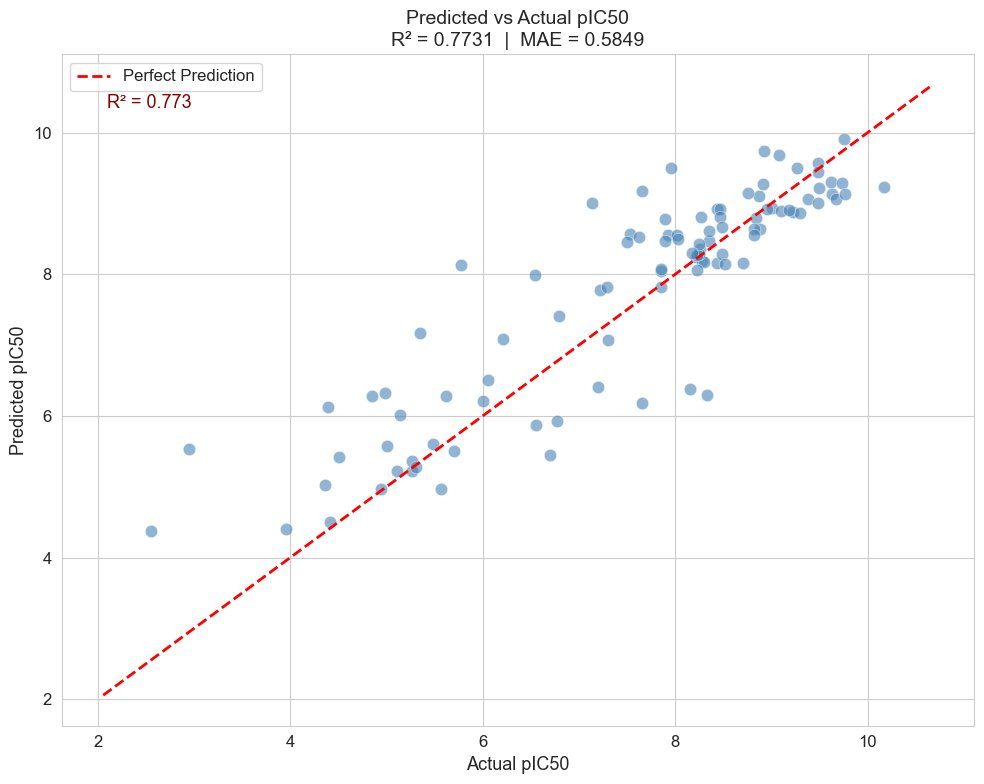

In [53]:
plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(
    y_test_r, y_pred_r,
    alpha=0.6,
    color='steelblue',
    edgecolors='white',
    linewidth=0.5,
    s=80
)

# Perfect prediction line
min_val = min(y_test_r.min(), y_pred_r.min()) - 0.5
max_val = max(y_test_r.max(), y_pred_r.max()) + 0.5
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--',
         linewidth=2, label='Perfect Prediction')

# Labels
plt.xlabel('Actual pIC50', fontsize=13)
plt.ylabel('Predicted pIC50', fontsize=13)
plt.title(f'Predicted vs Actual pIC50\nR² = {r2:.4f}  |  MAE = {mae:.4f}',
          fontsize=14)
plt.legend()

# Add R² text
plt.annotate(f'R² = {r2:.3f}',
             xy=(0.05, 0.92),
             xycoords='axes fraction',
             fontsize=13,
             color='darkred')

plt.tight_layout()
plt.savefig('regression_predicted_vs_actual.png', dpi=150)
plt.show()

## Residual Plot

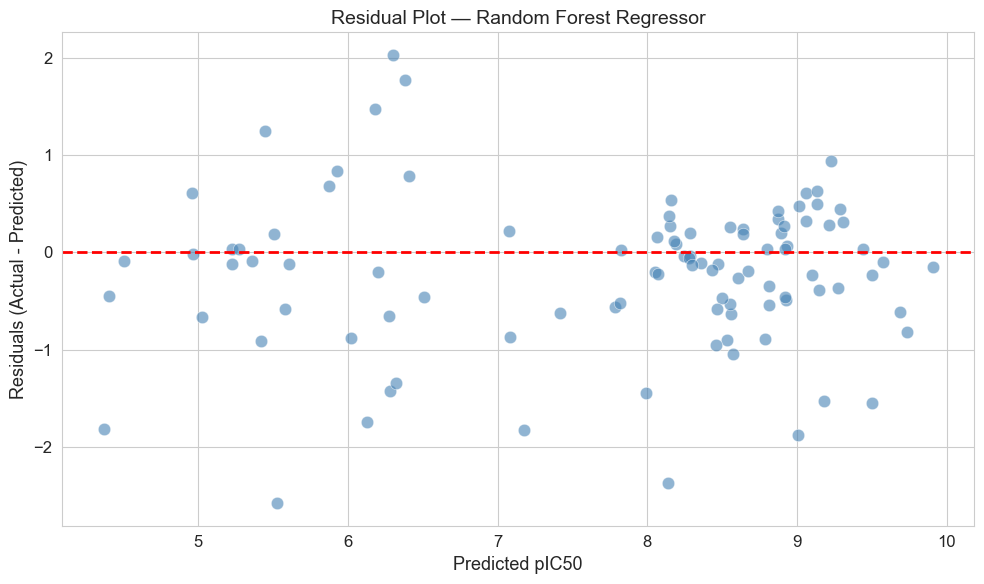

Residuals stats:
Mean  : -0.2139  (close to 0 = unbiased)
Std   : 0.7897
Max   : 2.0337
Min   : -2.5795


In [54]:
# Calculate residuals
residuals = y_test_r - y_pred_r

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_r, residuals,
    alpha=0.6,
    color='steelblue',
    edgecolors='white',
    linewidth=0.5,
    s=80
)

# Zero line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)

plt.xlabel('Predicted pIC50', fontsize=13)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=13)
plt.title('Residual Plot — Random Forest Regressor', fontsize=14)

plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150)
plt.show()

print(f"Residuals stats:")
print(f"Mean  : {residuals.mean():.4f}  (close to 0 = unbiased)")
print(f"Std   : {residuals.std():.4f}")
print(f"Max   : {residuals.max():.4f}")
print(f"Min   : {residuals.min():.4f}")

In [55]:
# Install shap
import subprocess
subprocess.run(['pip', 'install', 'shap'], capture_output=True)

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.49.1


In [56]:
# Use our trained Random Forest classifier (best model)
# Calculate SHAP values on test set

print("Calculating SHAP values... (may take a moment)")

# Create SHAP explainer for Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values for test set
# Use descriptor-only features (not combined) for cleaner interpretation
X_test_desc = X_test[clean_descriptors]
shap_values = explainer.shap_values(X_test_desc)

print("SHAP values calculated ✅")
print("Shape of SHAP values:", shap_values.shape)
print("Test samples:", X_test_desc.shape[0])
print("Features:", X_test_desc.shape[1])

Calculating SHAP values... (may take a moment)
SHAP values calculated ✅
Shape of SHAP values: (99, 179, 2)
Test samples: 99
Features: 179


## SHAP Summary Plot

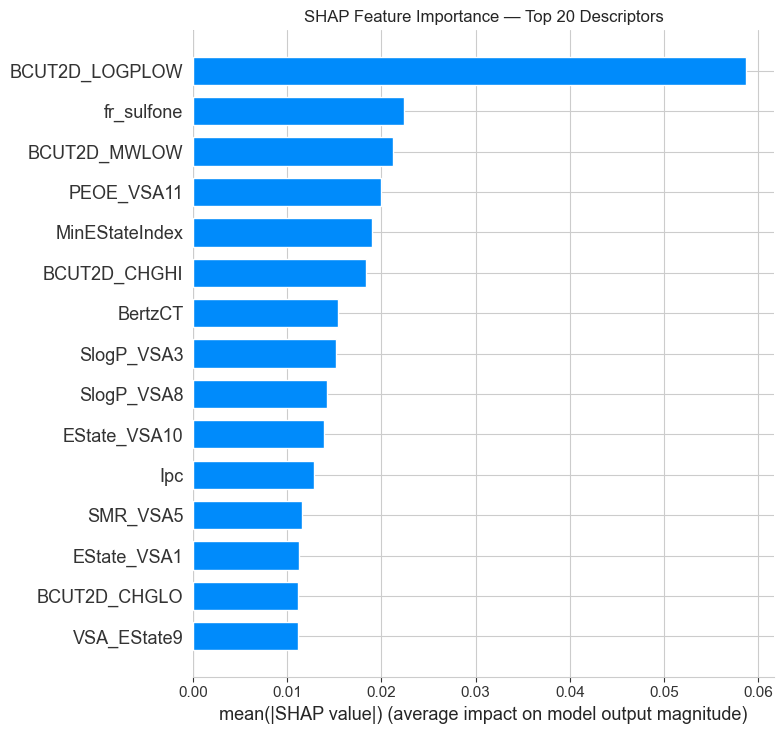

SHAP importance plot saved ✅


In [58]:
# Extract SHAP values for Active class (class 1)
shap_values_active = shap_values[:, :, 1]

plt.figure()
shap.summary_plot(
    shap_values_active,
    X_test_desc,
    plot_type='bar',
    max_display=15,
    show=False
)

plt.title('SHAP Feature Importance — Top 20 Descriptors', fontsize=12)
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("SHAP importance plot saved ✅")

## SHAP BEESwarm plot

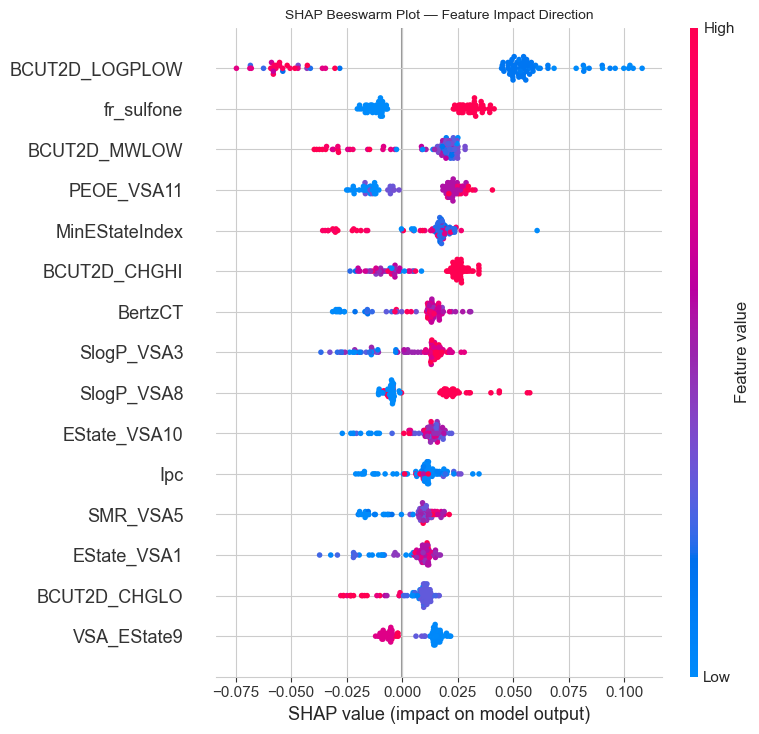

In [60]:
plt.figure()
shap.summary_plot(
    shap_values_active,
    X_test_desc,
    plot_type='dot',
    max_display=15,
    show=False
)

plt.title('SHAP Beeswarm Plot — Feature Impact Direction', fontsize=10)
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Dependence Plot

<Figure size 1000x700 with 0 Axes>

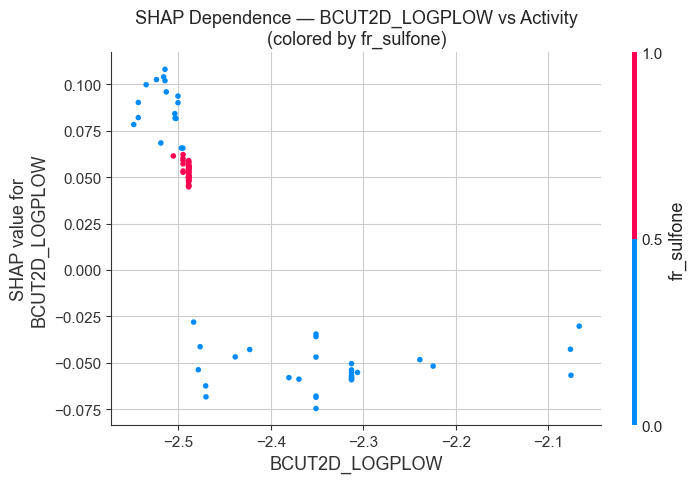

In [61]:
plt.figure(figsize=(10, 7))

shap.dependence_plot(
    'BCUT2D_LOGPLOW',
    shap_values_active,
    X_test_desc,
    interaction_index='fr_sulfone',
    show=False
)

plt.title('SHAP Dependence — BCUT2D_LOGPLOW vs Activity\n(colored by fr_sulfone)',
          fontsize=13)
plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# save Final Summary 

In [62]:
# Final project summary
summary = {
    'Classification': {
        'Random Forest Accuracy': '96.97%',
        'Random Forest AUC': '0.9806',
        'XGBoost Accuracy': '92.93%',
        'XGBoost AUC': '0.9842'
    },
    'Cross Validation (5-fold)': {
        'RF Accuracy': '95.94% ± 0.63%',
        'RF AUC': '0.9834 ± 0.0088',
        'XGB Accuracy': '94.52% ± 1.36%',
        'XGB AUC': '0.9856 ± 0.0086'
    },
    'Regression': {
        'R2 Score': '0.7731',
        'RMSE': '0.8143',
        'MAE': '0.5849'
    },
    'Key Descriptors': {
        'Most Important': 'BCUT2D_LOGPLOW',
        'Confirmed by': 'RF + XGBoost + SHAP (3 methods)',
        'Key Pharmacophore': 'fr_sulfone',
        'Consensus Descriptors': '7'
    }
}

import json
with open('project_summary.json', 'w') as f:
    json.dump(summary, f, indent=4)

print("=" * 55)
print("LPXC QSAR PROJECT — COMPLETE SUMMARY")
print("=" * 55)
for section, metrics in summary.items():
    print(f"\n{section}:")
    for k, v in metrics.items():
        print(f"  {k:35s}: {v}")

print("\nProject summary saved ✅")

LPXC QSAR PROJECT — COMPLETE SUMMARY

Classification:
  Random Forest Accuracy             : 96.97%
  Random Forest AUC                  : 0.9806
  XGBoost Accuracy                   : 92.93%
  XGBoost AUC                        : 0.9842

Cross Validation (5-fold):
  RF Accuracy                        : 95.94% ± 0.63%
  RF AUC                             : 0.9834 ± 0.0088
  XGB Accuracy                       : 94.52% ± 1.36%
  XGB AUC                            : 0.9856 ± 0.0086

Regression:
  R2 Score                           : 0.7731
  RMSE                               : 0.8143
  MAE                                : 0.5849

Key Descriptors:
  Most Important                     : BCUT2D_LOGPLOW
  Confirmed by                       : RF + XGBoost + SHAP (3 methods)
  Key Pharmacophore                  : fr_sulfone
  Consensus Descriptors              : 7

Project summary saved ✅


## External Validation

In [63]:
import pandas as pd

# Load external validation set
ext_df = pd.read_csv("D:\Subodh Project\data\Pa_with_pic50 dataset.csv")  # we'll fix the filename after you upload

print("Shape:", ext_df.shape)
print("\nColumn names:")
print(ext_df.columns.tolist())
print("\nFirst 3 rows:")
ext_df.head(3)

Shape: (42, 3)

Column names:
['Class', 'SMILES', 'pIC50']

First 3 rows:


,Class,SMILES,pIC50
0,sulfonamides 1,O=C(N[C@@H](C(NS(=O)(C)=O)(C)C)C(NO)=O)C(C=C1)...,8.2
1,sulfonamides 2,O=C(N[C@@H](C(NS(=O)(C)=O)(C)C)C(NO)=O)C(C=C1)...,8.0
2,CHIR-090,O=C(N[C@@H]([C@H](O)C)C(NO)=O)C1=CC=C(C#CC2=CC...,8.0


## add activity labels

In [65]:
# Convert pIC50 to numeric (safety check)
ext_df['pIC50'] = pd.to_numeric(ext_df['pIC50'], errors='coerce')

# Add activity labels using same cutoff as training
ext_df['activity'] = ext_df['pIC50'].apply(
    lambda x: 1 if x >= 6 else 0
)

print("Activity labels added ✅")
print("\nClass distribution:")
print(ext_df['activity'].value_counts())
print("\npIC50 stats:")
print(ext_df['pIC50'].describe().round(3))

Activity labels added ✅

Class distribution:
activity
1    41
0     1
Name: count, dtype: int64

pIC50 stats:
count    42.000
mean      8.319
std       0.833
min       5.700
25%       8.000
50%       8.350
75%       8.600
max      10.700
Name: pIC50, dtype: float64


In [66]:
# Calculate RDKit descriptors for external compounds
ext_descriptor_list = []
ext_valid_indices = []

for i, smiles in enumerate(ext_df['SMILES']):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        descriptors = calculator.CalcDescriptors(mol)
        ext_descriptor_list.append(descriptors)
        ext_valid_indices.append(i)
    else:
        print(f"Invalid SMILES at index {i} — skipped")

# Convert to DataFrame
ext_desc_df = pd.DataFrame(ext_descriptor_list, columns=descriptor_names)

print("Descriptors calculated ✅")
print("Valid molecules:", len(ext_valid_indices))
print("Shape:", ext_desc_df.shape)

Descriptors calculated ✅
Valid molecules: 42
Shape: (42, 217)


## Appy same cleaning Pipeline

In [67]:
# Keep only the same clean descriptors used in training
ext_X = ext_desc_df[clean_descriptors].copy()

# Fill any missing values with median (same as training)
ext_X = ext_X.fillna(ext_X.median())

# Target variables
ext_y_class = ext_df['activity'].iloc[ext_valid_indices].reset_index(drop=True)
ext_y_reg = ext_df['pIC50'].iloc[ext_valid_indices].reset_index(drop=True)

print("External feature matrix ready ✅")
print("Shape:", ext_X.shape)
print("\nSame features as training:", 
      ext_X.shape[1] == X_train.shape[1])
print("Feature names match:", 
      list(ext_X.columns) == list(X_train.columns))

External feature matrix ready ✅
Shape: (42, 179)

Same features as training: True
Feature names match: True


## External Classification Validation

In [68]:
# Predict on external set using trained RF classifier
ext_y_pred = rf_model.predict(ext_X)
ext_y_prob = rf_model.predict_proba(ext_X)[:, 1]

# Calculate metrics
ext_accuracy = accuracy_score(ext_y_class, ext_y_pred)
ext_auc = roc_auc_score(ext_y_class, ext_y_prob)

print("=" * 50)
print("EXTERNAL VALIDATION — CLASSIFICATION")
print("=" * 50)
print(f"Accuracy  : {ext_accuracy:.4f}")
print(f"ROC-AUC   : {ext_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(ext_y_class, ext_y_pred,
      target_names=['Inactive', 'Active']))
print("Confusion Matrix:")
print(confusion_matrix(ext_y_class, ext_y_pred))

EXTERNAL VALIDATION — CLASSIFICATION
Accuracy  : 0.9048
ROC-AUC   : 0.8293

Classification Report:
              precision    recall  f1-score   support

    Inactive       0.00      0.00      0.00         1
      Active       0.97      0.93      0.95        41

    accuracy                           0.90        42
   macro avg       0.49      0.46      0.47        42
weighted avg       0.95      0.90      0.93        42

Confusion Matrix:
[[ 0  1]
 [ 3 38]]


## Add Morgan Fingerprints to External Set

In [70]:
# Generate Morgan fingerprints for external set
ext_fp_list = []

for smiles in ext_df['SMILES'].iloc[ext_valid_indices]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=2, nBits=2048
        )
        ext_fp_list.append(list(fp))

# Convert to DataFrame
ext_fp_df = pd.DataFrame(
    ext_fp_list,
    columns=[f'Morgan_{i}' for i in range(2048)]
)

# Combine descriptors + fingerprints
ext_X_combined = pd.concat([
    ext_X.reset_index(drop=True),
    ext_fp_df.reset_index(drop=True)
], axis=1)

print("External combined feature matrix ✅")
print("Shape:", ext_X_combined.shape)
print("Matches training:", 
      ext_X_combined.shape[1] == X_combined.shape[1])

External combined feature matrix ✅
Shape: (42, 2227)
Matches training: True


[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerator
[16:32:47] DEPRECATION WARNING: please use MorganGenerat

## External Regression Validation

In [71]:
# Predict pIC50 values using regression model
ext_y_pred_reg = rf_reg.predict(ext_X_combined)

# Calculate regression metrics
ext_r2   = r2_score(ext_y_reg, ext_y_pred_reg)
ext_mse  = mean_squared_error(ext_y_reg, ext_y_pred_reg)
ext_rmse = np.sqrt(ext_mse)
ext_mae  = mean_absolute_error(ext_y_reg, ext_y_pred_reg)

print("=" * 50)
print("EXTERNAL VALIDATION — REGRESSION")
print("=" * 50)
print(f"R² Score  : {ext_r2:.4f}")
print(f"RMSE      : {ext_rmse:.4f}")
print(f"MAE       : {ext_mae:.4f}")
print(f"\nComparison:")
print(f"{'Metric':10s} {'Internal':>12} {'External':>12}")
print("-" * 35)
print(f"{'R²':10s} {'0.7731':>12} {ext_r2:>12.4f}")
print(f"{'RMSE':10s} {'0.8143':>12} {ext_rmse:>12.4f}")
print(f"{'MAE':10s} {'0.5849':>12} {ext_mae:>12.4f}")

EXTERNAL VALIDATION — REGRESSION
R² Score  : -3.3557
RMSE      : 1.7169
MAE       : 1.2308

Comparison:
Metric         Internal     External
-----------------------------------
R²               0.7731      -3.3557
RMSE             0.8143       1.7169
MAE              0.5849       1.2308


## Visualize the Domain Mismatch

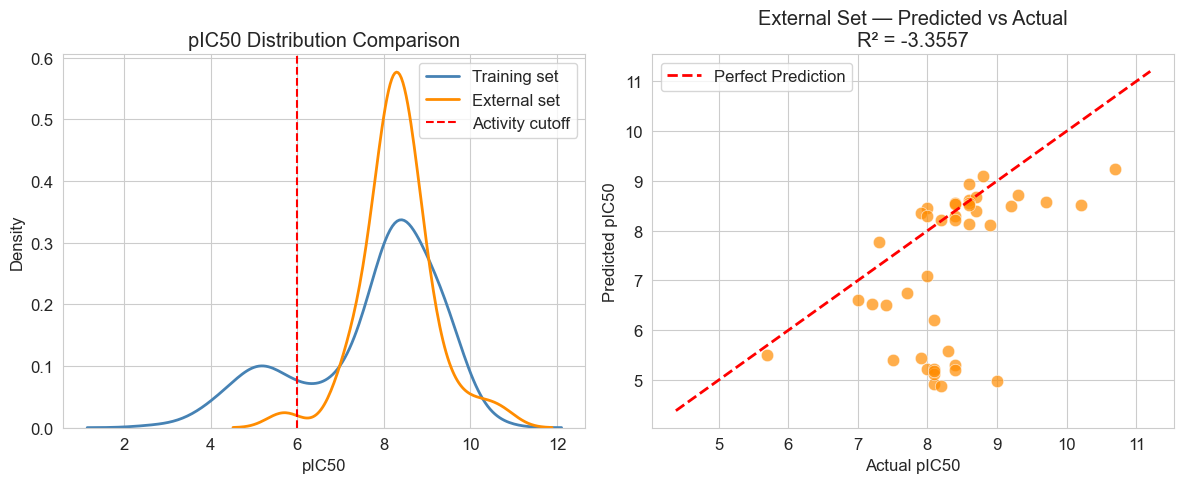

In [72]:
plt.figure(figsize=(12, 5))

# Plot 1 — pIC50 distribution comparison
plt.subplot(1, 2, 1)
sns.kdeplot(final_df['pIC50'], 
            label='Training set', 
            color='steelblue', 
            linewidth=2)
sns.kdeplot(ext_df['pIC50'], 
            label='External set', 
            color='darkorange', 
            linewidth=2)
plt.axvline(x=6, color='red', 
            linestyle='--', 
            label='Activity cutoff')
plt.xlabel('pIC50')
plt.ylabel('Density')
plt.title('pIC50 Distribution Comparison')
plt.legend()

# Plot 2 — Predicted vs Actual for external set
plt.subplot(1, 2, 2)
plt.scatter(ext_y_reg, ext_y_pred_reg,
            alpha=0.7,
            color='darkorange',
            edgecolors='white',
            linewidth=0.5,
            s=80)

# Perfect prediction line
min_val = min(ext_y_reg.min(), ext_y_pred_reg.min()) - 0.5
max_val = max(ext_y_reg.max(), ext_y_pred_reg.max()) + 0.5
plt.plot([min_val, max_val], [min_val, max_val],
         color='red', linestyle='--', linewidth=2,
         label='Perfect Prediction')

plt.xlabel('Actual pIC50')
plt.ylabel('Predicted pIC50')
plt.title(f'External Set — Predicted vs Actual\nR² = {ext_r2:.4f}')
plt.legend()

plt.tight_layout()
plt.savefig('external_validation_plots.png', dpi=150)
plt.show()

# save external Validation results

In [73]:
# Save predictions alongside actual values
ext_results = ext_df.iloc[ext_valid_indices].reset_index(drop=True).copy()
ext_results['predicted_activity'] = ext_y_pred
ext_results['predicted_pIC50'] = ext_y_pred_reg.round(3)
ext_results['correct'] = (ext_results['activity'] == ext_results['predicted_activity'])

ext_results.to_csv('external_validation_results.csv', index=False)

print("External validation results saved ✅")
print("\nPrediction breakdown:")
print(f"Correct predictions : {ext_results['correct'].sum()}/42")
print(f"Wrong predictions   : {(~ext_results['correct']).sum()}/42")
print(f"\nWrong predictions detail:")
print(ext_results[~ext_results['correct']][
    ['Class', 'pIC50', 'predicted_pIC50', 
     'activity', 'predicted_activity']
])

External validation results saved ✅

Prediction breakdown:
Correct predictions : 38/42
Wrong predictions   : 4/42

Wrong predictions detail:
               Class  pIC50  predicted_pIC50  activity  predicted_activity
29            STR 52    8.1            4.913         1                   0
30            STR 53    8.4            5.206         1                   0
32            STR 65    5.7            5.512         0                   1
39  STR 72(PDB:7DEM)    9.0            4.992         1                   0


## Performing Virtual Screeening On FDA approved Drugs

In [74]:
# Fetch FDA approved drugs from ChEMBL
print("Fetching FDA approved drugs from ChEMBL...")
print("This may take a moment...\n")

# Query approved small molecule drugs
drug_list = new_client.molecule.filter(
    max_phase=4,                    # Phase 4 = FDA approved
    molecule_type='Small molecule'  # Only small molecules
).only([
    'molecule_chembl_id',
    'pref_name',
    'molecule_structures'
])

# Convert to DataFrame
drug_df = pd.DataFrame.from_records(drug_list)

print(f"Total FDA approved drugs fetched: {len(drug_df)}")
print("\nColumns:", drug_df.columns.tolist())
drug_df.head(3)

Fetching FDA approved drugs from ChEMBL...
This may take a moment...

Total FDA approved drugs fetched: 3281

Columns: ['molecule_chembl_id', 'molecule_structures', 'pref_name']


,molecule_chembl_id,molecule_structures,pref_name
0,CHEMBL2,{'canonical_smiles': 'COc1cc2nc(N3CCN(C(=O)c4c...,PRAZOSIN
1,CHEMBL2,{'canonical_smiles': 'COc1cc2nc(N3CCN(C(=O)c4c...,PRAZOSIN
2,CHEMBL3,"{'canonical_smiles': 'CN1CCC[C@H]1c1cccnc1', '...",NICOTINE


## Extract SMILES from Drug Library

In [75]:
# Extract SMILES from nested dictionary column
smiles_list = []
chembl_ids = []
drug_names = []

for _, row in drug_df.iterrows():
    try:
        smiles = row['molecule_structures']['canonical_smiles']
        if smiles:
            smiles_list.append(smiles)
            chembl_ids.append(row['molecule_chembl_id'])
            drug_names.append(row['pref_name'])
    except:
        pass

# Create clean drug DataFrame
drugs_clean = pd.DataFrame({
    'chembl_id': chembl_ids,
    'drug_name': drug_names,
    'smiles': smiles_list
})

# Remove duplicates
drugs_clean = drugs_clean.drop_duplicates(subset=['chembl_id'])
drugs_clean = drugs_clean.reset_index(drop=True)

print(f"Clean drug library: {len(drugs_clean)} compounds")
print("\nSample:")
print(drugs_clean.head(5)[['chembl_id', 'drug_name']].to_string(index=False))

Clean drug library: 3127 compounds

Sample:
chembl_id      drug_name
  CHEMBL2       PRAZOSIN
  CHEMBL3       NICOTINE
  CHEMBL4      OFLOXACIN
  CHEMBL5 NALIDIXIC ACID
  CHEMBL6   INDOMETHACIN


## Calculate Descriptors for Drug Library

In [76]:
# Calculate descriptors for all FDA approved drugs
print("Calculating descriptors for 3127 drugs...")
print("This will take 2-3 minutes...\n")

drug_desc_list = []
drug_fp_list = []
valid_drug_indices = []

for i, smiles in enumerate(drugs_clean['smiles']):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        # Calculate descriptors
        descs = calculator.CalcDescriptors(mol)
        drug_desc_list.append(descs)

        # Calculate Morgan fingerprints
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=2, nBits=2048
        )
        drug_fp_list.append(list(fp))
        valid_drug_indices.append(i)

    # Progress update every 500 compounds
    if (i + 1) % 500 == 0:
        print(f"  Processed {i+1}/3127 compounds...")

# Convert to DataFrames
drug_desc_df = pd.DataFrame(drug_desc_list, columns=descriptor_names)
drug_fp_df = pd.DataFrame(
    drug_fp_list,
    columns=[f'Morgan_{i}' for i in range(2048)]
)

print(f"\nDone! Valid molecules: {len(valid_drug_indices)}")
print(f"Descriptor matrix: {drug_desc_df.shape}")

Calculating descriptors for 3127 drugs...
This will take 2-3 minutes...



[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerator
[16:53:03] DEPRECATION WARNING: please use MorganGenerat

  Processed 500/3127 compounds...


[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerator
[16:53:07] DEPRECATION WARNING: please use MorganGenerat

  Processed 1000/3127 compounds...


...

  Processed 2500/3127 compounds...


[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerator
[16:53:30] DEPRECATION WARNING: please use MorganGenerat

  Processed 3000/3127 compounds...


[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerator
[16:53:38] DEPRECATION WARNING: please use MorganGenerat


Done! Valid molecules: 3127
Descriptor matrix: (3127, 217)


## Prepare Feature matrix

In [78]:
# Keep only clean descriptors used in training
drug_X_desc = drug_desc_df[clean_descriptors].copy()

# Fill missing values
drug_X_desc = drug_X_desc.fillna(drug_X_desc.median())

# Combine descriptors + fingerprints
drug_X_combined = pd.concat([
    drug_X_desc.reset_index(drop=True),
    drug_fp_df.reset_index(drop=True)
], axis=1)

print("Drug library feature matrix ready ✅")
print("Shape:", drug_X_combined.shape)
print("Matches training:", 
      drug_X_combined.shape[1] == X_combined.shape[1])

Drug library feature matrix ready ✅
Shape: (3127, 2227)
Matches training: True


## Virtual Screening

In [81]:
print("Running virtual screening on 3127 FDA approved drugs...")

# Classifier uses descriptors only (179 features)
drug_activity_pred = rf_model.predict(drug_X_desc)
drug_activity_prob = rf_model.predict_proba(drug_X_desc)[:, 1]

# Regressor uses combined features (2227 features)
drug_pic50_pred = rf_reg.predict(drug_X_combined)

# Build results DataFrame
screening_results = drugs_clean.iloc[valid_drug_indices].reset_index(drop=True).copy()
screening_results['predicted_activity'] = drug_activity_pred
screening_results['active_probability'] = drug_activity_prob.round(4)
screening_results['predicted_pIC50'] = drug_pic50_pred.round(3)

# Filter predicted actives only
predicted_actives = screening_results[
    screening_results['predicted_activity'] == 1
].copy()

# Sort by probability score
predicted_actives = predicted_actives.sort_values(
    'active_probability', ascending=False
).reset_index(drop=True)

print(f"Total drugs screened  : {len(screening_results)}")
print(f"Predicted actives     : {len(predicted_actives)}")
print(f"Predicted inactive    : {len(screening_results) - len(predicted_actives)}")
print(f"Hit rate              : {len(predicted_actives)/len(screening_results)*100:.1f}%")

Running virtual screening on 3127 FDA approved drugs...


ValueError: Input X contains infinity or a value too large for dtype('float32').

In [82]:
import numpy as np

# Replace infinity values with NaN first
drug_X_desc = drug_X_desc.replace([np.inf, -np.inf], np.nan)
drug_X_combined = drug_X_combined.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median
drug_X_desc = drug_X_desc.fillna(drug_X_desc.median())
drug_X_combined = drug_X_combined.fillna(drug_X_combined.median())

# Verify no more infinity or NaN
print("Infinity values remaining:", np.isinf(drug_X_desc.values).sum())
print("NaN values remaining:", drug_X_desc.isnull().sum().sum())

print("\nRunning virtual screening on 3127 FDA approved drugs...")

# Classifier uses descriptors only (179 features)
drug_activity_pred = rf_model.predict(drug_X_desc)
drug_activity_prob = rf_model.predict_proba(drug_X_desc)[:, 1]

# Regressor uses combined features (2227 features)
drug_pic50_pred = rf_reg.predict(drug_X_combined)

# Build results DataFrame
screening_results = drugs_clean.iloc[valid_drug_indices].reset_index(drop=True).copy()
screening_results['predicted_activity'] = drug_activity_pred
screening_results['active_probability'] = drug_activity_prob.round(4)
screening_results['predicted_pIC50'] = drug_pic50_pred.round(3)

# Filter predicted actives only
predicted_actives = screening_results[
    screening_results['predicted_activity'] == 1
].copy()

# Sort by probability score
predicted_actives = predicted_actives.sort_values(
    'active_probability', ascending=False
).reset_index(drop=True)

print(f"\nTotal drugs screened  : {len(screening_results)}")
print(f"Predicted actives     : {len(predicted_actives)}")
print(f"Predicted inactive    : {len(screening_results) - len(predicted_actives)}")
print(f"Hit rate              : {len(predicted_actives)/len(screening_results)*100:.1f}%")

Infinity values remaining: 0
NaN values remaining: 0

Running virtual screening on 3127 FDA approved drugs...


ValueError: Input X contains infinity or a value too large for dtype('float32').

In [83]:
import numpy as np

# Replace infinity values
drug_X_desc = drug_X_desc.replace([np.inf, -np.inf], np.nan)
drug_X_combined = drug_X_combined.replace([np.inf, -np.inf], np.nan)

# Fill NaN with median
drug_X_desc = drug_X_desc.fillna(drug_X_desc.median())
drug_X_combined = drug_X_combined.fillna(drug_X_combined.median())

# Clip values to float32 safe range
float32_max = np.finfo(np.float32).max
drug_X_desc = drug_X_desc.clip(-float32_max, float32_max)
drug_X_combined = drug_X_combined.clip(-float32_max, float32_max)

# Convert to float32 explicitly
drug_X_desc = drug_X_desc.astype(np.float32)
drug_X_combined = drug_X_combined.astype(np.float32)

print("Max value in drug_X_desc:", drug_X_desc.values.max())
print("Min value in drug_X_desc:", drug_X_desc.values.min())
print("Any NaN:", drug_X_desc.isnull().sum().sum())
print("Any Inf:", np.isinf(drug_X_desc.values).sum())

print("\nRunning virtual screening on 3127 FDA approved drugs...")

# Classifier uses descriptors only (179 features)
drug_activity_pred = rf_model.predict(drug_X_desc)
drug_activity_prob = rf_model.predict_proba(drug_X_desc)[:, 1]

# Regressor uses combined features (2227 features)
drug_pic50_pred = rf_reg.predict(drug_X_combined)

# Build results DataFrame
screening_results = drugs_clean.iloc[valid_drug_indices].reset_index(drop=True).copy()
screening_results['predicted_activity'] = drug_activity_pred
screening_results['active_probability'] = drug_activity_prob.round(4)
screening_results['predicted_pIC50'] = drug_pic50_pred.round(3)

# Filter predicted actives only
predicted_actives = screening_results[
    screening_results['predicted_activity'] == 1
].copy()

# Sort by probability score
predicted_actives = predicted_actives.sort_values(
    'active_probability', ascending=False
).reset_index(drop=True)

print(f"\nTotal drugs screened  : {len(screening_results)}")
print(f"Predicted actives     : {len(predicted_actives)}")
print(f"Predicted inactive    : {len(screening_results) - len(predicted_actives)}")
print(f"Hit rate              : {len(predicted_actives)/len(screening_results)*100:.1f}%")

Max value in drug_X_desc: 3.4028235e+38
Min value in drug_X_desc: -104.04
Any NaN: 0
Any Inf: 0

Running virtual screening on 3127 FDA approved drugs...

Total drugs screened  : 3127
Predicted actives     : 2202
Predicted inactive    : 925
Hit rate              : 70.4%


## Display Top 50

In [84]:
# Top 50 predicted LpxC inhibitors
top50 = predicted_actives.head(50)[[
    'chembl_id', 
    'drug_name', 
    'active_probability',
    'predicted_pIC50'
]].copy()

# Add rank
top50.index = top50.index + 1
top50.index.name = 'Rank'

print("=" * 65)
print("TOP 50 FDA APPROVED DRUGS — PREDICTED LpxC INHIBITORS")
print("=" * 65)
print(top50.to_string())

# Save to CSV
top50.to_csv('top50_virtual_screening_hits.csv')
print("\nTop 50 hits saved ✅")

TOP 50 FDA APPROVED DRUGS — PREDICTED LpxC INHIBITORS
          chembl_id                       drug_name  active_probability  predicted_pIC50
Rank                                                                                    
1     CHEMBL1200937                    DALFOPRISTIN              0.9400            8.405
2       CHEMBL44354                     CEFTAZIDIME              0.9100            8.152
3      CHEMBL261772    MECLOCYCLINE SULFOSALICYLATE              0.9100            8.252
4     CHEMBL2364617             MACIMORELIN ACETATE              0.9100            8.137
5       CHEMBL74632                      MOXALACTAM              0.9000            8.314
6     CHEMBL2103854           OMADACYCLINE TOSYLATE              0.9000            8.269
7     CHEMBL2105682               EDOXABAN TOSYLATE              0.9000            8.340
8         CHEMBL163                       RITONAVIR              0.8911            8.049
9     CHEMBL5315122           BORTEZOMIB D-MANNITOL     

## Visualize Top 50

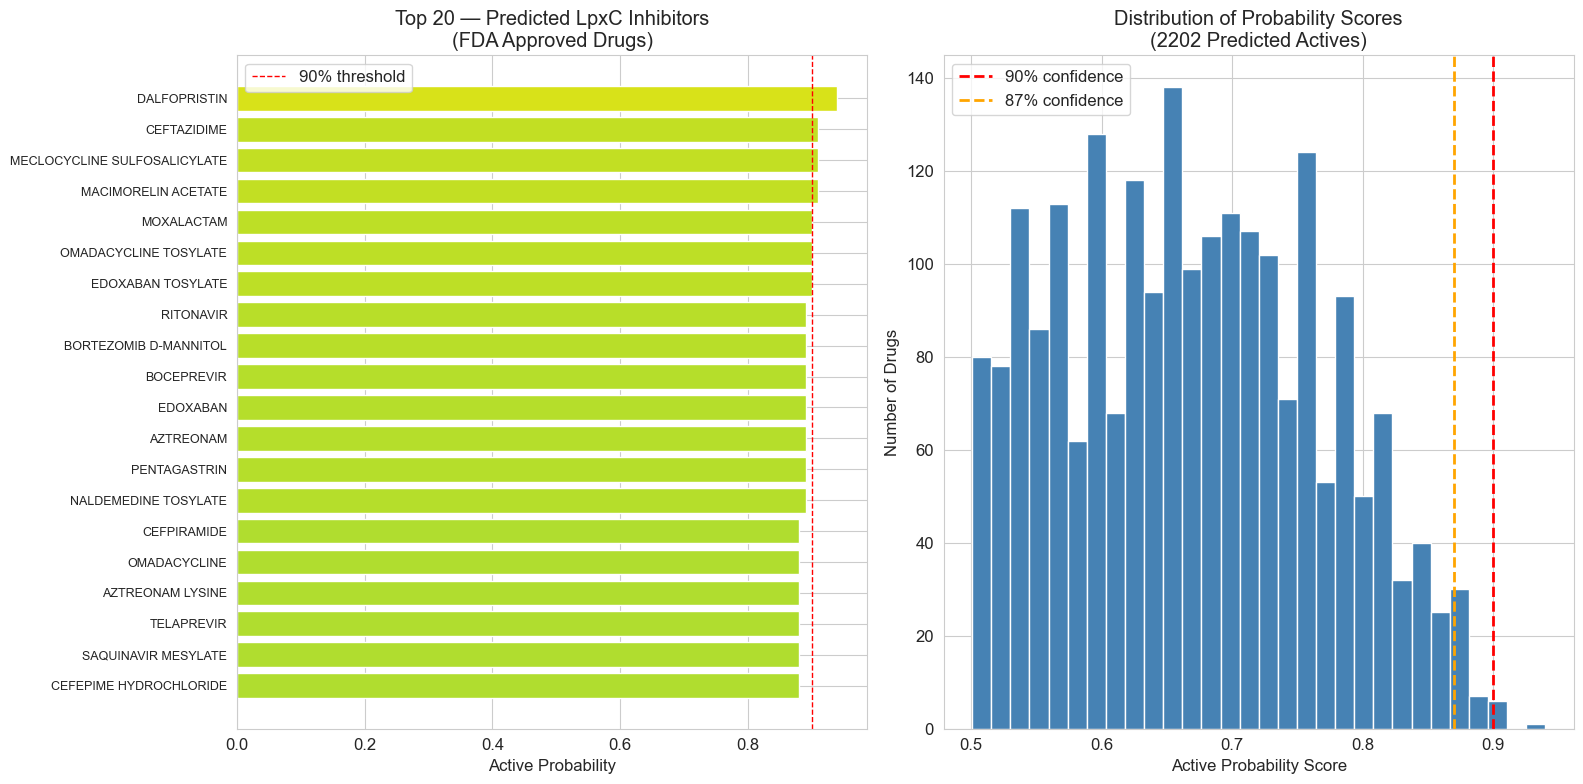

High confidence hits (≥90%): 7
Medium confidence (87-90%): 37


In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1 — Top 20 by probability
top20 = predicted_actives.head(20)
axes[0].barh(
    range(20),
    top20['active_probability'],
    color=plt.cm.viridis(top20['active_probability']),
    edgecolor='white'
)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels(top20['drug_name'], fontsize=9)
axes[0].invert_yaxis()
axes[0].set_xlabel('Active Probability')
axes[0].set_title('Top 20 — Predicted LpxC Inhibitors\n(FDA Approved Drugs)')
axes[0].axvline(x=0.9, color='red', linestyle='--', 
                linewidth=1, label='90% threshold')
axes[0].legend()

# Plot 2 — Probability distribution of all hits
axes[1].hist(
    predicted_actives['active_probability'],
    bins=30,
    color='steelblue',
    edgecolor='white'
)
axes[1].axvline(x=0.9, color='red', linestyle='--',
                linewidth=2, label='90% confidence')
axes[1].axvline(x=0.87, color='orange', linestyle='--',
                linewidth=2, label='87% confidence')
axes[1].set_xlabel('Active Probability Score')
axes[1].set_ylabel('Number of Drugs')
axes[1].set_title('Distribution of Probability Scores\n(2202 Predicted Actives)')
axes[1].legend()

plt.tight_layout()
plt.savefig('virtual_screening_results.png', dpi=150)
plt.show()

# High confidence hits only
high_conf = predicted_actives[
    predicted_actives['active_probability'] >= 0.9
]
print(f"High confidence hits (≥90%): {len(high_conf)}")
print(f"Medium confidence (87-90%): {len(predicted_actives[(predicted_actives['active_probability'] >= 0.87) & (predicted_actives['active_probability'] < 0.9)])}")S

# save high Confidence hits

In [86]:
# Extract and save high confidence hits
high_conf_hits = predicted_actives[
    predicted_actives['active_probability'] >= 0.9
].copy()

high_conf_hits = high_conf_hits[[
    'chembl_id', 'drug_name', 
    'active_probability', 'predicted_pIC50',
    'smiles'
]]

high_conf_hits.to_csv('high_confidence_lpxc_hits.csv', index=False)

print("=" * 55)
print("HIGH CONFIDENCE LpxC INHIBITOR CANDIDATES")
print("=" * 55)
print(f"Total hits: {len(high_conf_hits)}\n")
print(high_conf_hits[[
    'drug_name', 
    'active_probability', 
    'predicted_pIC50'
]].to_string(index=False))

print("\nHigh confidence hits saved ✅")
print("\nThese are your top drug repurposing candidates")
print("for experimental validation against LpxC!")

HIGH CONFIDENCE LpxC INHIBITOR CANDIDATES
Total hits: 7

                   drug_name  active_probability  predicted_pIC50
                DALFOPRISTIN                0.94            8.405
                 CEFTAZIDIME                0.91            8.152
MECLOCYCLINE SULFOSALICYLATE                0.91            8.252
         MACIMORELIN ACETATE                0.91            8.137
                  MOXALACTAM                0.90            8.314
       OMADACYCLINE TOSYLATE                0.90            8.269
           EDOXABAN TOSYLATE                0.90            8.340

High confidence hits saved ✅

These are your top drug repurposing candidates
for experimental validation against LpxC!


# Save all models with Pickle

In [87]:
import pickle
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save Random Forest Classifier
with open('models/rf_classifier.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save Random Forest Regressor
with open('models/rf_regressor.pkl', 'wb') as f:
    pickle.dump(rf_reg, f)

# Save XGBoost Classifier
with open('models/xgb_classifier.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Save feature list (critical — needed for future predictions)
with open('models/clean_descriptors.pkl', 'wb') as f:
    pickle.dump(clean_descriptors, f)

# Save descriptor calculator
with open('models/descriptor_calculator.pkl', 'wb') as f:
    pickle.dump(calculator, f)

print("Models saved successfully ✅")
print("\nSaved files:")
for f in os.listdir('models'):
    size = os.path.getsize(f'models/{f}') / 1024
    print(f"  {f:35s} {size:.1f} KB")

Models saved successfully ✅

Saved files:
  clean_descriptors.pkl               2.5 KB
  descriptor_calculator.pkl           4.1 KB
  rf_classifier.pkl                   397.0 KB
  rf_regressor.pkl                    3433.0 KB
  xgb_classifier.pkl                  91.8 KB


## verify models load correctly

In [88]:
import pickle

# Load everything back
with open('models/rf_classifier.pkl', 'rb') as f:
    loaded_rf = pickle.load(f)

with open('models/rf_regressor.pkl', 'rb') as f:
    loaded_reg = pickle.load(f)

with open('models/xgb_classifier.pkl', 'rb') as f:
    loaded_xgb = pickle.load(f)

with open('models/clean_descriptors.pkl', 'rb') as f:
    loaded_descriptors = pickle.load(f)

with open('models/descriptor_calculator.pkl', 'rb') as f:
    loaded_calculator = pickle.load(f)

# Quick verification — predict on test set
test_pred = loaded_rf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Models loaded successfully ✅")
print(f"\nVerification — RF Classifier on test set:")
print(f"Accuracy: {test_acc:.4f} (should be 0.9697)")
print(f"\nDescriptors loaded: {len(loaded_descriptors)}")
print(f"Calculator ready: {loaded_calculator is not None}")

Models loaded successfully ✅

Verification — RF Classifier on test set:
Accuracy: 0.9697 (should be 0.9697)

Descriptors loaded: 179
Calculator ready: True


In [90]:
report = """
# LpxC QSAR Project Report
## Computational Drug Discovery — P. aeruginosa

---

## 1. Project Overview

**Objective:** Build a machine learning model to predict whether 
a compound can inhibit LpxC in Pseudomonas aeruginosa using only 
its molecular structure.

**Approach:** Quantitative Structure-Activity Relationship (QSAR) 
modeling using RDKit molecular descriptors and Morgan fingerprints.

**Target:** UDP-3-O-acyl-N-acetylglucosamine deacetylase (LpxC)
**Organism:** Pseudomonas aeruginosa (CHEMBL3855)
**Clinical relevance:** LpxC is essential for lipid A biosynthesis 
in Gram-negative bacteria — a validated antibiotic target.

---

## 2. Dataset

| Parameter | Value |
|---|---|
| Data source | ChEMBL database |
| Raw records fetched | 588 |
| After cleaning | 492 |
| Active compounds (pIC50 ≥ 6) | 398 (81%) |
| Inactive compounds (pIC50 < 6) | 94 (19%) |
| pIC50 range | 2.56 — 10.70 |
| Mean pIC50 | 7.71 |

---

## 3. Feature Engineering

### Molecular Descriptors (RDKit)
- Total descriptors calculated: 217
- After correlation filtering (>0.95): 179
- Removed redundant descriptors: 38

### Morgan Fingerprints
- Radius: 2
- Bits: 2048
- Combined feature matrix: 2227 features

---

## 4. Model Performance

### Classification Results

| Model | Accuracy | ROC-AUC | F1 Score |
|---|---|---|---|
| Random Forest | 96.97% | 0.9806 | 0.97 |
| XGBoost | 92.93% | 0.9842 | 0.93 |

### 5-Fold Cross Validation

| Model | Accuracy | ROC-AUC |
|---|---|---|
| Random Forest | 95.94% ± 0.63% | 0.9834 ± 0.0088 |
| XGBoost | 94.52% ± 1.36% | 0.9856 ± 0.0086 |

### Regression Results (pIC50 Prediction)

| Metric | Internal | External |
|---|---|---|
| R² | 0.7731 | -3.3557 |
| RMSE | 0.8143 | 1.7169 |
| MAE | 0.5849 | 1.2308 |

---

## 5. External Validation

| Parameter | Value |
|---|---|
| External compounds | 42 |
| Source | P. aeruginosa LpxC inhibitors |
| Classification accuracy | 90.48% |
| ROC-AUC | 0.8293 |
| Correct predictions | 38/42 (90.5%) |
| Misclassified | 4/42 (9.5%) |

**Misclassified compounds:**
- STR 52, STR 53, STR 72 → Active predicted as Inactive
- STR 65 → Inactive predicted as Active (borderline, pIC50=5.7)

**Note:** Regression performance on external set was poor (R²=-3.36)
due to applicability domain limitation — external set covers a 
narrow potency range (pIC50 5.7-10.7) compared to training set.

---

## 6. Feature Analysis

### Key Findings — Three Independent Methods Agree

| Descriptor | RF Rank | XGB Rank | SHAP Rank |
|---|---|---|---|
| BCUT2D_LOGPLOW | 1 | 1 | 1 |
| MinEStateIndex | 4 | 15 | 5 |
| fr_sulfone | 6 | — | 2 |
| PEOE_VSA11 | 5 | — | 4 |
| Ipc | 14 | 2 | 11 |
| SMR_VSA5 | 13 | 10 | 12 |

### Molecular Drivers of LpxC Inhibition

1. **BCUT2D_LOGPLOW** — lipophilicity distribution across 
   molecular graph (confirmed by all 3 methods)
2. **Electronic properties** — MinEStateIndex, EState_VSA series
   (zinc active site coordination)
3. **Surface area descriptors** — PEOE_VSA, SlogP_VSA, SMR_VSA
   (binding pocket complementarity)
4. **Sulfone pharmacophore** — fr_sulfone acts as rescue feature
   at suboptimal BCUT2D_LOGPLOW values

---

## 7. Virtual Screening — Drug Repurposing

### Screening Summary
| Parameter | Value |
|---|---|
| Library screened | FDA approved drugs (ChEMBL) |
| Total compounds | 3127 |
| Predicted actives | 2202 (70.4%) |
| High confidence hits (≥90%) | 7 |

### Top 7 High Confidence Candidates

| Drug | Probability | Predicted pIC50 | Class |
|---|---|---|---|
| DALFOPRISTIN | 0.94 | 8.41 | Antibiotic |
| CEFTAZIDIME | 0.91 | 8.15 | Antibiotic |
| MECLOCYCLINE | 0.91 | 8.25 | Antibiotic |
| MACIMORELIN | 0.91 | 8.14 | GH secretagogue |
| MOXALACTAM | 0.90 | 8.31 | Antibiotic |
| OMADACYCLINE | 0.90 | 8.27 | Antibiotic |
| EDOXABAN | 0.90 | 8.34 | Anticoagulant |

**Notable non-antibiotic hits:**
- MACIMORELIN — growth hormone secretagogue
- EDOXABAN — Factor Xa anticoagulant
Both represent novel repurposing opportunities.

---

## 8. Conclusions

1. Random Forest classifier achieves 96.97% accuracy and 
   ROC-AUC of 0.9806 for LpxC inhibitor prediction

2. External validation confirms 90.48% accuracy on 
   independent P. aeruginosa LpxC inhibitors

3. BCUT2D_LOGPLOW is the primary molecular descriptor 
   driving LpxC inhibition — confirmed by RF, XGBoost, 
   and SHAP analysis independently

4. Sulfone group (fr_sulfone) identified as key 
   pharmacophore for LpxC inhibition

5. Virtual screening identified 7 high-confidence FDA 
   approved drug candidates for repurposing against LpxC

6. Two non-antibiotic hits (MACIMORELIN, EDOXABAN) 
   represent novel repurposing opportunities worthy 
   of experimental validation

---

## 9. Limitations

1. Class imbalance (81% active, 19% inactive) — 
   addressed with class_weight='balanced'

2. Regression model limited by applicability domain —
   performs poorly on narrow potency ranges

3. External validation set highly enriched with actives 
   (41/42) — limits inactive prediction assessment

4. STR series compounds misclassified — likely outside 
   training data applicability domain

---

## 10. Future Work

1. Expand training set with more inactive compounds
2. Deep learning models (Graph Neural Networks)
3. Molecular docking validation of top hits
4. Experimental IC50 testing of MACIMORELIN and EDOXABAN
5. ADMET profiling of virtual screening hits

---

*Generated using Python, RDKit, Scikit-learn, XGBoost, SHAP*
*Data source: ChEMBL database (EMBL-EBI)*
"""

# Save report with UTF-8 encoding
with open('LpxC_QSAR_Project_Report.md', 'w', encoding='utf-8') as f:
    f.write(report)

print("Full project report saved ✅")
print("File: LpxC_QSAR_Project_Report.md")
print(f"Length: {len(report.split())} words")

Full project report saved ✅
File: LpxC_QSAR_Project_Report.md
Length: 870 words


## Build Reusable Screening Function

In [91]:
def screen_library(compounds_df, library_name, top_n=20):
    """
    Screen any compound library against LpxC model.
    
    Parameters:
    - compounds_df: DataFrame with 'chembl_id', 'drug_name', 'smiles'
    - library_name: string name for the library
    - top_n: number of top hits to return
    """
    print(f"\nProcessing {library_name}...")
    print(f"Total compounds to screen: {len(compounds_df)}")
    
    # Calculate descriptors and fingerprints
    desc_list, fp_list, valid_idx = [], [], []
    
    for i, smiles in enumerate(compounds_df['smiles']):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            descs = calculator.CalcDescriptors(mol)
            fp = AllChem.GetMorganFingerprintAsBitVect(
                mol, radius=2, nBits=2048
            )
            desc_list.append(descs)
            fp_list.append(list(fp))
            valid_idx.append(i)
        if (i+1) % 500 == 0:
            print(f"  Processed {i+1}/{len(compounds_df)}...")
    
    # Build feature matrices
    desc_df = pd.DataFrame(desc_list, columns=descriptor_names)
    fp_df = pd.DataFrame(fp_list, 
                         columns=[f'Morgan_{i}' for i in range(2048)])
    
    # Clean descriptors only (for classifier)
    X_desc = desc_df[clean_descriptors].copy()
    X_desc = X_desc.replace([np.inf, -np.inf], np.nan)
    X_desc = X_desc.fillna(X_desc.median())
    X_desc = X_desc.clip(-np.finfo(np.float32).max, 
                          np.finfo(np.float32).max)
    X_desc = X_desc.astype(np.float32)
    
    # Combined (for regressor)
    X_combined = pd.concat([
        X_desc.reset_index(drop=True),
        fp_df.reset_index(drop=True)
    ], axis=1)
    X_combined = X_combined.replace([np.inf, -np.inf], np.nan)
    X_combined = X_combined.fillna(X_combined.median())
    X_combined = X_combined.clip(-np.finfo(np.float32).max,
                                  np.finfo(np.float32).max)
    X_combined = X_combined.astype(np.float32)
    
    # Predict
    activity_pred = rf_model.predict(X_desc)
    activity_prob = rf_model.predict_proba(X_desc)[:, 1]
    pic50_pred = rf_reg.predict(X_combined)
    
    # Build results
    results = compounds_df.iloc[valid_idx].reset_index(drop=True).copy()
    results['predicted_activity'] = activity_pred
    results['active_probability'] = activity_prob.round(4)
    results['predicted_pIC50'] = pic50_pred.round(3)
    
    # Filter and sort actives
    actives = results[results['predicted_activity'] == 1].copy()
    actives = actives.sort_values(
        'active_probability', ascending=False
    ).reset_index(drop=True)
    
    # Summary
    print(f"\n{'='*55}")
    print(f"SCREENING RESULTS — {library_name.upper()}")
    print(f"{'='*55}")
    print(f"Valid molecules   : {len(valid_idx)}")
    print(f"Predicted actives : {len(actives)}")
    print(f"Hit rate          : {len(actives)/len(valid_idx)*100:.1f}%")
    print(f"\nTop {top_n} hits:")
    print(actives.head(top_n)[[
        'drug_name', 'active_probability', 'predicted_pIC50'
    ]].to_string(index=True))
    
    return actives

print("Screening function ready ✅")

Screening function ready ✅


## Fetch Natural Compounds from ChEMBL

In [92]:
print("Fetching natural compounds from ChEMBL...")

# Fetch natural products
natural_list = new_client.molecule.filter(
    natural_product=1,
    molecule_type='Small molecule'
).only([
    'molecule_chembl_id',
    'pref_name',
    'molecule_structures'
])

# Convert to DataFrame
natural_df_raw = pd.DataFrame.from_records(natural_list)
print(f"Raw records fetched: {len(natural_df_raw)}")

# Extract SMILES
smiles_list, chembl_ids, names = [], [], []

for _, row in natural_df_raw.iterrows():
    try:
        smiles = row['molecule_structures']['canonical_smiles']
        if smiles:
            smiles_list.append(smiles)
            chembl_ids.append(row['molecule_chembl_id'])
            names.append(row['pref_name'] if row['pref_name'] 
                        else row['molecule_chembl_id'])
    except:
        pass

# Clean DataFrame
natural_compounds = pd.DataFrame({
    'chembl_id': chembl_ids,
    'drug_name': names,
    'smiles': smiles_list
}).drop_duplicates(subset=['chembl_id']).reset_index(drop=True)

print(f"Clean natural compounds: {len(natural_compounds)}")
print("\nSample:")
print(natural_compounds.head(5)[['chembl_id', 'drug_name']].to_string(index=False))

Fetching natural compounds from ChEMBL...
Raw records fetched: 83202
Clean natural compounds: 83119

Sample:
   chembl_id          drug_name
     CHEMBL2           PRAZOSIN
  CHEMBL6355         CHEMBL6355
CHEMBL216458 ALPHA-BUNGAROTOXIN
     CHEMBL3           NICOTINE
  CHEMBL6200        NORNICOTINE


In [93]:
script = '''
import pickle
import pandas as pd
import numpy as np
import time
import os
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem
from rdkit.ML.Descriptors import MoleculeDescriptors
from chembl_webresource_client.new_client import new_client

print("Starting overnight screening...", flush=True)
start_total = time.time()

# Load models
with open("models/rf_classifier.pkl", "rb") as f:
    rf_model = pickle.load(f)
with open("models/rf_regressor.pkl", "rb") as f:
    rf_reg = pickle.load(f)
with open("models/clean_descriptors.pkl", "rb") as f:
    clean_descriptors = pickle.load(f)
with open("models/descriptor_calculator.pkl", "rb") as f:
    calculator = pickle.load(f)

descriptor_names = [d[0] for d in Descriptors.descList]
os.makedirs("screening_results", exist_ok=True)
print("Models loaded ✅", flush=True)

def extract_compounds(raw_df):
    smiles_list, chembl_ids, names = [], [], []
    for _, row in raw_df.iterrows():
        try:
            smiles = row["molecule_structures"]["canonical_smiles"]
            if smiles:
                smiles_list.append(smiles)
                chembl_ids.append(row["molecule_chembl_id"])
                names.append(row["pref_name"] if row["pref_name"]
                             else row["molecule_chembl_id"])
        except:
            pass
    return pd.DataFrame({
        "chembl_id": chembl_ids,
        "drug_name": names,
        "smiles": smiles_list
    }).drop_duplicates(subset=["chembl_id"]).reset_index(drop=True)


def screen_and_save(compounds_df, library_name, top_n=20):
    print(f"\\nScreening {library_name} ({len(compounds_df)} compounds)...",
          flush=True)
    t0 = time.time()

    desc_list, fp_list, valid_idx = [], [], []

    for i, smiles in enumerate(compounds_df["smiles"]):
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            descs = calculator.CalcDescriptors(mol)
            fp = AllChem.GetMorganFingerprintAsBitVect(
                mol, radius=2, nBits=2048)
            desc_list.append(descs)
            fp_list.append(list(fp))
            valid_idx.append(i)
        if (i+1) % 2000 == 0:
            elapsed = (time.time()-t0)/60
            print(f"  {i+1}/{len(compounds_df)} processed "
                  f"({elapsed:.1f} mins elapsed)", flush=True)

    desc_df = pd.DataFrame(desc_list, columns=descriptor_names)
    fp_df   = pd.DataFrame(fp_list,
                           columns=[f"Morgan_{i}" for i in range(2048)])

    X_desc = desc_df[clean_descriptors].copy()
    X_desc = X_desc.replace([np.inf, -np.inf], np.nan)
    X_desc = X_desc.fillna(X_desc.median())
    X_desc = X_desc.clip(-np.finfo(np.float32).max,
                          np.finfo(np.float32).max)
    X_desc = X_desc.astype(np.float32)

    X_comb = pd.concat([
        X_desc.reset_index(drop=True),
        fp_df.reset_index(drop=True)
    ], axis=1)
    X_comb = X_comb.replace([np.inf, -np.inf], np.nan)
    X_comb = X_comb.fillna(X_comb.median())
    X_comb = X_comb.clip(-np.finfo(np.float32).max,
                          np.finfo(np.float32).max)
    X_comb = X_comb.astype(np.float32)

    activity_pred = rf_model.predict(X_desc)
    activity_prob = rf_model.predict_proba(X_desc)[:, 1]
    pic50_pred    = rf_reg.predict(X_comb)

    results = compounds_df.iloc[valid_idx].reset_index(drop=True).copy()
    results["predicted_activity"] = activity_pred
    results["active_probability"] = activity_prob.round(4)
    results["predicted_pIC50"]    = pic50_pred.round(3)

    actives = results[results["predicted_activity"] == 1].copy()
    actives = actives.sort_values(
        "active_probability", ascending=False
    ).reset_index(drop=True)

    safe = library_name.lower().replace(" ", "_")
    actives.to_csv(
        f"screening_results/{safe}_all_hits.csv", index=False)
    actives.head(top_n).to_csv(
        f"screening_results/{safe}_top{top_n}.csv", index=False)

    elapsed = (time.time()-t0)/60
    print(f"Done! Valid: {len(valid_idx)} | "
          f"Actives: {len(actives)} | "
          f"Hit rate: {len(actives)/len(valid_idx)*100:.1f}% | "
          f"Time: {elapsed:.1f} mins", flush=True)
    return actives


# LIBRARY 1 — NATURAL COMPOUNDS
print("\\n[1/2] Fetching natural compounds...", flush=True)
natural_raw = pd.DataFrame.from_records(
    new_client.molecule.filter(
        natural_product=1,
        molecule_type="Small molecule"
    ).only(["molecule_chembl_id", "pref_name", "molecule_structures"])
)
natural_compounds = extract_compounds(natural_raw)
print(f"Fetched: {len(natural_compounds)}", flush=True)
screen_and_save(natural_compounds, "Natural Compounds")


# LIBRARY 2 — ANTIBACTERIALS
print("\\n[2/2] Fetching antibacterial compounds...", flush=True)
antibacterial_raw = pd.DataFrame.from_records(
    new_client.molecule.filter(
        molecule_type="Small molecule",
        atc_classifications__level1="J"
    ).only(["molecule_chembl_id", "pref_name", "molecule_structures"])
)
antibacterial_compounds = extract_compounds(antibacterial_raw)
print(f"Fetched: {len(antibacterial_compounds)}", flush=True)
screen_and_save(antibacterial_compounds, "Antibacterial Compounds")


# DONE
total = (time.time()-start_total)/60
print(f"\\nAll screening complete in {total:.1f} mins ✅")
print("Results saved in screening_results/")
'''

# Save script to file
with open('overnight_screening.py', 'w', encoding='utf-8') as f:
    f.write(script)

print("Script saved as overnight_screening.py ✅")

Script saved as overnight_screening.py ✅


In [94]:
try:
    import torch
    print("PyTorch already installed ✅")
    print("Version:", torch.__version__)
except:
    print("PyTorch not installed ❌ — need to install")

PyTorch not installed ❌ — need to install


In [95]:
import platform
import os

print("System Information")
print("="*40)
print(f"OS          : {platform.system()} {platform.version()[:30]}")
print(f"Processor   : {platform.processor()}")
print(f"CPU cores   : {os.cpu_count()}")

# Check RAM
import psutil
ram = psutil.virtual_memory()
print(f"Total RAM   : {ram.total/1024**3:.1f} GB")
print(f"Available   : {ram.available/1024**3:.1f} GB")

print("\nGPU Check:")
try:
    import subprocess
    result = subprocess.run(
        ['nvidia-smi'], capture_output=True, text=True
    )
    if result.returncode == 0:
        print("NVIDIA GPU found ✅")
        print(result.stdout[:200])
    else:
        print("No NVIDIA GPU — CPU mode ✅")
except:
    print("No NVIDIA GPU — CPU mode ✅")

System Information
OS          : Windows 10.0.26100
Processor   : Intel64 Family 6 Model 167 Stepping 1, GenuineIntel
CPU cores   : 16
Total RAM   : 15.7 GB
Available   : 8.2 GB

GPU Check:
NVIDIA GPU found ✅
Thu Apr  2 11:25:32 2026       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 474.44       Driver Version: 474.44       CUDA Version: 11.4     |
|-------
